<a href="https://colab.research.google.com/github/deepankverma/coolpaths/blob/main/notebooks/Coolpaths.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [97]:
! rm -r outputs/ *.csv *.jpg

rm: cannot remove '*.csv': No such file or directory


In [1]:
#@title Install dependencies (run once in Colab)
!pip install pvlib osmnx rasterio geopandas pybdshadow earthengine-api numpy topocalc geemap ipyleaflet timezonefinder pythermalcomfort

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 17.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.4/18.4 MB 59.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyter_packaging-0.12.3-py3-none-any.whl.metadata (7.7 kB)
  Using cached comm-0.2.3-py3-none-any.whl.metadata (3.7 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jedi-0.19.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached async_lru-2.2.0-py3-none-any.whl.metadata (7.2 kB)
  Using cached jupyter_lsp-2.3.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyterlab_server-2.28.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached json5-0.13.0-py3-none-any.whl.metadata (36 kB)
   ━━━━━

In [1]:
folder = "test_simcity"
prefix = "Paris"
# prefix = "Paris" (48.8575, 2.3514)
# prefix = "Mumbai" (18.9582, 72.8321)
# prefix = "Manhattan" (40.7685, -73.9822)
# prefix = "Berlin" (52.5200, 13.4050)
# prefix = "Tokyo" (35.6895, 139.6917)
# prefix = "London" (51.5074, -0.1278)
# prefix = "Mexico City" (19.4326, -99.1332)
# prefix = "Cape Town" (-33.9249, 18.4241)
# prefix = "Sao Paulo"
# latlong = (-23.5505, -46.6333)
# prefix = "Los Angeles"
# latlong = (34.0522, -118.2437)
# prefix = "Toronto"
# latlong = (43.6532, -79.3832)
# prefix = "Buenos Aires"
# latlong = (-34.6037, -58.3816)
# prefix = "Cairo"
# latlong = (30.0444, 31.2357)
# prefix = "Lagos"
# latlong = (6.5244, 3.3792)
# prefix = "Johannesburg"
# latlong = (-26.2041, 28.0473)
# prefix = "Jakarta"
# latlong = (-6.2088, 106.8456)
# prefix = "Bangkok"
# latlong = (13.7563, 100.5018)
# prefix = "Seoul"
# latlong = (37.5665, 126.9780)
# prefix = "Istanbul"
# latlong = (41.0082, 28.9784)
# prefix = "Santiago"
# latlong = (-33.4489, -70.6693)
# prefix = "Auckland"
# latlong = (-36.8485, 174.7633)
# prefix = "Perth"
# latlong = (-31.9523, 115.8613)
# prefix = "Montevideo"
# latlong Montevideo= (-34.9011, -56.1645)
# prefix = "Madrid"
latlong = (48.8575, 2.3514)



In [2]:
#@title BBOX Picker

import math
from ipywidgets import Output
from timezonefinder import TimezoneFinder
from zoneinfo import ZoneInfo
from ipyleaflet import Map, DrawControl, Rectangle
import ipywidgets as widgets
from google.colab import output
from datetime import date
from IPython.display import display

# Enables widget support in Colab
output.enable_custom_widget_manager()

# Initialize map
m = Map(center=latlong, zoom=15)


# Configure drawing control
draw_control = DrawControl()
draw_control.rectangle = {
    "shapeOptions": {"color": "#ff0000", "fillOpacity": 0.1}
}
draw_control.polygon = {}
draw_control.polyline = {}
draw_control.circle = {}
draw_control.circlemarker = {}

# Output widget
output_widget = Output()
display(m, output_widget)

saved_bbox = None
saved_tz = None  # will hold the ZoneInfo for this bbox

def handle_draw(dc, action, geo_json):
    global saved_bbox, saved_tz
    with output_widget:
        output_widget.clear_output()
        if action == 'created' and geo_json['geometry']['type'] == 'Polygon':
            # 1) Compute center of the drawn bbox
            coords = geo_json['geometry']['coordinates'][0]
            lats = [pt[1] for pt in coords]
            lons = [pt[0] for pt in coords]
            center_lat = sum(lats) / len(lats)
            center_lon = sum(lons) / len(lons)

            # 2) Build a 1 km square around that center
            half_km = 0.5
            delta_lat = half_km / 110.574
            delta_lon = half_km / (111.320 * math.cos(math.radians(center_lat)))
            min_lat = center_lat - delta_lat
            max_lat = center_lat + delta_lat
            min_lon = center_lon - delta_lon
            max_lon = center_lon + delta_lon
            saved_bbox = (min_lon, min_lat, max_lon, max_lat)
            print("1 km square BBox (W, S, E, N):", saved_bbox)

            # 3) Detect its timezone
            tf = TimezoneFinder()
            tz_name = tf.timezone_at(lat=center_lat, lng=center_lon)
            if tz_name:
                saved_tz = ZoneInfo(tz_name)
                print("Detected timezone:", tz_name)
            else:
                saved_tz = ZoneInfo("UTC")
                print("Timezone lookup failed; defaulting to UTC.")

            # 4) Remove any previous fixed‐size rectangles
            for layer in list(m.layers):
                if isinstance(layer, Rectangle):
                    m.remove_layer(layer)

            # 5) Draw the new 1 km rectangle
            fixed_rect = Rectangle(
                bounds=((min_lat, min_lon), (max_lat, max_lon)),
                color="blue",
                fill=False,
                weight=2
            )
            m.add_layer(fixed_rect)

draw_control.on_draw(handle_draw)
m.add_control(draw_control)


Map(center=[48.8575, 2.3514], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoo…

Output()

In [3]:
#@title Date and Hour Picker

# show a calendar and let the user pick
date_picker = widgets.DatePicker(
    description='Select date:',
    # value=date.today(),       # defaults to today
    value=date(2024, 6, 21),
    disabled=False
)
hours_slider = widgets.IntRangeSlider(
    description='Hours Range:',
    min=0, max=23, step=1,
    value=[12, 12],             # default 08:00–18:00
    continuous_update=False
)

display(date_picker, hours_slider)

DatePicker(value=datetime.date(2024, 6, 21), description='Select date:', step=1)

IntRangeSlider(value=(12, 12), continuous_update=False, description='Hours Range:', max=23)

In [4]:
#@title Main functions

# simcity.py
# Integrated pipeline:

# ── Imports & logger setup ─────────────────────────────────────────────────────
from __future__ import annotations
import datetime as _dt
import logging, time, requests, shutil
from datetime import timezone
from math import tan, radians, sin, cos
from pathlib import Path
from typing import Tuple, Optional
import os
import glob
import pandas as pd
import numpy as np
import geopandas as gpd
import osmnx as ox
import pvlib
import rasterio
from rasterio.features import rasterize, shapes
from rasterio.warp import reproject, Resampling
from rasterio import transform as rio_transform
from rasterio.transform import xy
from shapely.geometry import box, shape
from shapely import affinity
import matplotlib.pyplot as plt
from rasterio.plot import show
import pybdshadow
from topocalc.viewf import viewf
from scipy.ndimage import gaussian_filter
from pvlib.atmosphere import kasten96_lt, alt2pres, get_relative_airmass, get_absolute_airmass
from pvlib.clearsky import ineichen
from datetime import datetime, date, timedelta, timezone, time as dt_time
import matplotlib as mpl
import ee
from pyproj import Transformer

import warnings
warnings.filterwarnings("ignore")

# Logger setup
_log = logging.getLogger("simcity")
if not _log.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter(
        "%(asctime)s | %(levelname)-7s | %(message)s", datefmt="%H:%M:%S"
    ))
    _log.addHandler(h)
_log.setLevel(logging.INFO)


# ------------shared raster template based on bbox and desired resolution
def create_template_raster(
    bbox: Tuple[float, float, float, float],
    resolution: float,
    crs: str = "EPSG:3857",
    dst: Path = Path("outputs/template.tif")
) -> Path:
    from rasterio.transform import from_origin
    import rasterio
    import numpy as np

    west, south, east, north = bbox
    # Reproject bbox to target CRS for proper width/height
    bounds_geom = gpd.GeoSeries([box(west, south, east, north)], crs=4326).to_crs(crs)
    west, south, east, north = bounds_geom.total_bounds

    width = int(np.ceil((east - west) / resolution))
    height = int(np.ceil((north - south) / resolution))
    transform = from_origin(west, north, resolution, resolution)

    meta = {
        "driver": "GTiff",
        "height": height,
        "width": width,
        "count": 1,
        "dtype": "uint8",
        "crs": crs,
        "transform": transform,
    }
    with rasterio.open(dst, "w", **meta) as dst_r:
        dst_r.write(np.zeros((height, width), dtype="uint8"), 1)
    return dst

# ── Helper to plot any GeoTIFF inline ──────────────────────────────────────────
# def plot_raster(path: str, title: str = None, cmap: str = "viridis", figsize=(4, 4)):
#     """
#     Open a GeoTIFF and plot it inline
#     """
#     with rasterio.open(path) as src:
#         fig, ax = plt.subplots(figsize=figsize)
#         show(src, ax=ax, cmap=cmap)
#         if title:
#             ax.set_title(title)
#         ax.axis("on")
#         plt.show()

# def plot_raster(path: str, title: str = None, cmap: str = "viridis", figsize=(3, 3)):
#     """
#     Open a GeoTIFF and plot it inline, with a colorbar legend.
#     """
#     with rasterio.open(path) as src:
#         data = src.read(1)
#         fig, ax = plt.subplots(figsize=figsize)
#         # show the raster
#         show(src, ax=ax, cmap=cmap)
#         # add a colorbar
#         vmin, vmax = np.nanmin(data), np.nanmax(data)
#         norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
#         sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
#         sm.set_array(data)
#         cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
#         # cbar.set_label("Value", rotation=270, labelpad=15)
#         # title & axes
#         if title:
#             ax.set_title(title)
#         ax.axis("off")
#         plt.show()


def plot_raster(
    path: str,
    title: str = None,
    cmap: str = "viridis",
    figsize=(3, 3),
    save_path: str = None,
    dpi: int = 300
):
    """
    Open a GeoTIFF and plot it inline, with a colorbar legend.
    If save_path is provided, saves the figure at the given dpi.
    """
    with rasterio.open(path) as src:
        data = src.read(1)
        fig, ax = plt.subplots(figsize=figsize)
        # show the raster
        show(src, ax=ax, cmap=cmap)
        # add a colorbar
        vmin, vmax = np.nanmin(data), np.nanmax(data)
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array(data)
        fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
        # title & axes
        if title:
            ax.set_title(title)
        ax.axis("off")
        # save to file if requested
        if save_path:
            fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
        plt.show()


##for clipping shadows
def clip_raster_to_template(
    src_tif: str,
    template_tif: str,
    dst_tif: str
) -> Path:
    import rasterio
    import numpy as np
    from rasterio.warp import reproject, Resampling

    with rasterio.open(src_tif) as src, rasterio.open(template_tif) as tmpl:
        out = np.zeros((tmpl.height, tmpl.width), dtype="uint8")
        reproject(
            source=src.read(1),
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=tmpl.transform,
            dst_crs=tmpl.crs,
            resampling=Resampling.nearest
        )
        meta = tmpl.meta.copy()
    meta.update(dtype="uint8", count=1)

    with rasterio.open(dst_tif, "w", **meta) as dst_r:
        dst_r.write(out, 1)
    return Path(dst_tif)


# ── 1. Download buildings & streets from OSM ────────────────────────────────────
def _download_osm(bbox: Tuple[float,float,float,float], network_type: str = "walk"
) -> Tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]:
    west, south, east, north = bbox
    poly = box(west, south, east, north)
    tags = {"building": True}
    b = (ox.features_from_polygon(poly, tags)
         if hasattr(ox, "features_from_polygon")
         else ox.geometries_from_polygon(poly, tags))
    b = b[[c for c in ["geometry","height","building:levels"] if c in b.columns]].reset_index(drop=True)
    G = ox.graph_from_polygon(poly, network_type=network_type)
    streets = ox.graph_to_gdfs(G, nodes=False, edges=True)
    return b, streets


def _clip_to_bbox(gdf: gpd.GeoDataFrame, bbox: Tuple[float, float, float, float]) -> gpd.GeoDataFrame:
    clip_geom = gpd.GeoSeries([box(*bbox)], crs=4326)
    if gdf.crs != clip_geom.crs:
        clip_geom = clip_geom.to_crs(gdf.crs)
    return gpd.clip(gdf, clip_geom)

# ── 2. Buffer footpaths ─────────────────────────────────────────────────────────
def _footpaths(streets: gpd.GeoDataFrame, buf: float = 2.0) -> gpd.GeoDataFrame:
    if not streets.crs or streets.crs.to_epsg() != 3857:
        streets = streets.to_crs(3857)
    return streets.buffer(buf).rename("geometry").to_frame().reset_index(drop=True)

# ── 3. Estimate building heights ────────────────────────────────────────────────
def _est_h(row: pd.Series, default_levels: int = 2, floor_height: float = 3.0) -> float:
    h = row.get("height", None)
    if pd.notnull(h):
        try:
            return float(str(h).replace("m", ""))
        except:
            pass
    lv = row.get("building:levels", None)
    if pd.notnull(lv):
        try:
            return float(lv) * floor_height
        except:
            pass
    return default_levels * floor_height

def _enrich(b: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    df = b.copy()
    df["est_height_m"] = df.apply(_est_h, axis=1)
    df["centroid_z"] = df["est_height_m"] / 2.0
    return df



## with pybdshadow ##############
def _shadow_raster_pybdshadow(
    buildings: gpd.GeoDataFrame,
    time_utc: _dt.datetime,
    template_tif: str,
    dst: Path | str = "shadow_buildings_pybd.tif"
) -> Optional[Path]:
    # Ensure 'height' column is numeric
    if buildings['height'].dtype != float:
        buildings['height'] = buildings['height'].astype(float)

    # 1. Compute vector shadows using pybdshadow
    #    pybdshadow expects input in WGS84; ensures buildings are in EPSG:4326
    buildings_wgs = buildings.to_crs(epsg=4326)
    shadows = pybdshadow.bdshadow_sunlight(
        buildings=buildings_wgs,
        date=time_utc,
        height="height",
        roof=False,
        include_building=False,
        ground=0
    )

    if shadows.empty:
        _log.warning("No shadows generated; skipping.")
        return None

    # 1b. Reproject shadows to template CRS for rasterization
    with rasterio.open(template_tif) as tmpl:
        meta = tmpl.meta.copy()
        out_shape = (tmpl.height, tmpl.width)
        transform = tmpl.transform
        target_crs = tmpl.crs
    shadows = shadows.to_crs(target_crs)

    # 2. Rasterize shadow geometries
    mask = rasterize(
        [(geom, 1) for geom in shadows.geometry],
        out_shape=out_shape,
        transform=transform,
        fill=0,
        dtype="uint8"
    )

    # 3. Write to disk
    meta.update(dtype="uint8", count=1)
    out_path = Path(dst)
    with rasterio.open(out_path, "w", **meta) as dst_r:
        dst_r.write(mask, 1)

    return out_path

### FOR SHADOWS UNDER THE TREE
def tree_transmissivity_for_date(d, lat, profile="deciduous"):
    """
    Return (tau_dir, tau_dif) for a given date and latitude.
      profile: "deciduous" (default) or "evergreen"
      lat: decimal degrees (+N, -S) to auto-flip seasons across hemispheres.
    Seasons (deciduous, N hemisphere):
      Leaf-on:  Apr 15 (DOY 105) .. Oct 15 (DOY 288)
      Leaf-off: otherwise
    S hemisphere: seasons are flipped.
    """
    if d is None:
        d = _date.today()
    doy = int(d.strftime("%j"))

    if profile.lower() == "evergreen":
        # Modest attenuation year-round (tweak if you have species info)
        return 0.15, 0.70  # more light leaks through evergreens

    # Deciduous: pick window by hemisphere
    leaf_on_start = 105  # Apr 15
    leaf_on_end   = 288  # Oct 15

    # Flip by hemisphere
    nh = (lat >= 0.0)
    if not nh:
        # In the south, leaf-on is approximately Oct 15 .. Apr 15 (wraps year end)
        leaf_on_start, leaf_on_end = 288, 105

    # Test if DOY is within the (possibly wrapping) leaf-on window
    if leaf_on_start <= leaf_on_end:
        leaf_on = (leaf_on_start <= doy <= leaf_on_end)
    else:
        leaf_on = (doy >= leaf_on_start or doy <= leaf_on_end)

    if leaf_on:
        tau_dir, tau_dif = 0.013, 0.50
    else:
        tau_dir, tau_dif = 0.60, 0.80

    return float(tau_dir), float(tau_dif)

# ── tree shadows via pybdshadow (preserving per-pixel heights) ─────────────────
def _shadow_raster_trees_pybdshadow(
    canopy_tif: str,
    time_utc: _dt.datetime,
    template_tif: str,
    dst: Path | str = "shadow_trees_pybd.tif"
) -> Optional[Path]:
    from rasterio.features import shapes as raster_shapes
    import numpy as np
    import geopandas as gpd

    # 1. Vectorize canopy DSM, preserving every pixel's height
    records = []
    with rasterio.open(canopy_tif) as src:
        canopy = src.read(1).astype(np.int32)  # supported integer dtype
        transform_src = src.transform
        crs_src = src.crs
        # extract polygons for all non-zero heights
        for geom, val in raster_shapes(canopy, mask=(canopy > 0), transform=transform_src):
            if val and geom.get('coordinates'):
                records.append({
                    "geometry": shape(geom),
                    "height": int(val)
                })
    if not records:
        _log.warning("No tree canopy pixels found; skipping tree shadows.")
        return None

    # 2. Build GeoDataFrame
    gdf = gpd.GeoDataFrame(records, crs=crs_src)
    # convert to WGS84 for pybdshadow
    gdf = gdf.to_crs(epsg=4326)

    # 3. Preprocess for pybdshadow
    gdf = pybdshadow.bd_preprocess(gdf, height="height")

    # 4. Compute vector shadows (WGS84)
    shadows = pybdshadow.bdshadow_sunlight(
        buildings=gdf,
        date=time_utc,
        height="height",
        roof=False,
        include_building=False,
        ground=0
    )
    if shadows.empty:
        _log.warning("No tree shadows generated; skipping.")
        return None

    # 5. Load template to get target CRS and raster parameters
    with rasterio.open(template_tif) as tmpl:
        meta = tmpl.meta.copy()
        out_shape = (tmpl.height, tmpl.width)
        transform = tmpl.transform
        target_crs = tmpl.crs

    # 6. Reproject shadows to template CRS and filter invalids
    shadows = shadows.to_crs(target_crs)
    shadows = shadows[~(shadows.geometry.is_empty | ~shadows.geometry.is_valid)]
    if shadows.empty:
        _log.warning("Shadows empty after reproject/validate; skipping.")
        return None

    # 7. Rasterize shadow geometries
    mask = rasterize(
        [(geom, 1) for geom in shadows.geometry],
        out_shape=out_shape,
        transform=transform,
        fill=0,
        dtype="uint8"
    )

    # 8. Write to disk
    meta.update(dtype="uint8", count=1)
    out_path = Path(dst)
    with rasterio.open(out_path, "w", **meta) as dst_r:
        dst_r.write(mask, 1)

    return out_path



# ── B. Vegetation mask from NDVI ───────────────────────────────────────────────
def write_vegetation_mask(
    ndvi_tif: str,
    threshold: float = 0.3,
    dst: Path | str = "vegetation_mask.tif",
    template_tif: str = None
) -> Path:
    with rasterio.open(ndvi_tif) as src:
        ndvi = src.read(1)
        ndvi_meta = src.meta.copy()
        veg = (ndvi > threshold).astype("uint8")
    if template_tif:
        with rasterio.open(template_tif) as tmpl:
            out_data = np.zeros((tmpl.height, tmpl.width), dtype="uint8")
            reproject(
                source=veg,
                destination=out_data,
                src_transform=ndvi_meta["transform"],
                src_crs=ndvi_meta["crs"],
                dst_transform=tmpl.transform,
                dst_crs=tmpl.crs,
                resampling=Resampling.nearest,
            )
            meta = tmpl.meta.copy()
            meta.update(dtype="uint8", count=1)
    else:
        out_data = veg
        meta = ndvi_meta
        meta.update(dtype="uint8", count=1)

    out = Path(dst)
    with rasterio.open(out, "w", **meta) as dst_r:
        dst_r.write(out_data, 1)
    return out

# ── C. Building footprint mask ────────────────────────────────────────────────
def write_building_mask(
    buildings: gpd.GeoDataFrame,
    template_tif: str,
    dst: Path | str = "building_mask.tif"
) -> Path:
    with rasterio.open(template_tif) as src:
        meta = src.meta.copy()
        transform = src.transform
        h, w = src.height, src.width
    b = buildings.to_crs(meta["crs"])
    mask = rasterize(
        [(g, 1) for g in b.geometry], out_shape=(h, w), transform=transform,
        fill=0, dtype="uint8"
    )
    meta.update(dtype="uint8", count=1)
    out = Path(dst)
    with rasterio.open(out, "w", **meta) as dst_r:
        dst_r.write(mask, 1)
    return out


def write_impervious_mask(
    veg_tif: str,
    bld_tif: str,
    water_tif: str,
    canopy_tif: str,
    dst: Path | str,
    template_tif: str = None
) -> Path:
    import rasterio
    from rasterio.warp import reproject, Resampling
    import numpy as np

    def load_aligned(path, template):
        with rasterio.open(path) as src, rasterio.open(template) as tmpl:
            data = src.read(1)
            out = np.zeros((tmpl.height, tmpl.width), dtype="uint8")
            reproject(
                source=data,
                destination=out,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=tmpl.transform,
                dst_crs=tmpl.crs,
                resampling=Resampling.nearest
            )
        return out

    # build the four masks (all 0/1 arrays aligned to template):
    veg       = load_aligned(veg_tif,    template_tif)   # 1 where vegetation
    bld       = load_aligned(bld_tif,    template_tif)   # 1 where building
    water     = load_aligned(water_tif,  template_tif)   # 1 where water
    canopy    = load_aligned(canopy_tif, template_tif)   # canopy height values

    # turn canopy heights into a binary tree mask
    tree_mask = (canopy > 0).astype("uint8")             # 1 where there’s any tree

    # impervious = buildings OR (not veg, not water, not tree)
    imp = (
            (veg   == 0)
          & (bld   == 0)
          & (water == 0)
          & (tree_mask == 0)
        ).astype("uint8")

    # write out
    with rasterio.open(template_tif) as tmpl:
        meta = tmpl.meta.copy()
    meta.update(dtype="uint8", count=1)

    out = Path(dst)
    with rasterio.open(out, "w", **meta) as dst_r:
        dst_r.write(imp, 1)

    return out



# ── EXPORT WATER MASK VIA ESA WORLDCOVER ───────────────────────────────────────
def _export_worldcover_water_to_drive(region, scale: int = 10):
    import ee
    # Load the WorldCover collection, take its first (and only) image
    wc = ee.ImageCollection("ESA/WorldCover/v200") \
           .first() \
           .select("Map") \
           .eq(80) \
           .rename("water_mask")
    task = ee.batch.Export.image.toDrive(
        image=wc.clip(region),
        description="export_worldcover_water_mask",
        folder=folder,
        fileNamePrefix=f"{prefix}_water_mask",
        region=region.coordinates().getInfo(),
        scale=scale,        # 10 m native resolution
        crs="EPSG:3857",
        maxPixels=1e13
    )

    return task


# ── WATER MASK READER ─────────────────────────────────────────────────────────
def write_water_mask(
    water_tif: str,
    dst: Path | str,
    template_tif: str = None
) -> Path:
    import rasterio
    from rasterio.warp import reproject, Resampling
    import numpy as np

    with rasterio.open(water_tif) as src, rasterio.open(template_tif) as tmpl:
        water = src.read(1)
        out_data = np.zeros((tmpl.height, tmpl.width), dtype="uint8")
        reproject(
            source=water,
            destination=out_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=tmpl.transform,
            dst_crs=tmpl.crs,
            resampling=Resampling.nearest
        )
        meta = tmpl.meta.copy()
    meta.update(dtype="uint8", count=1)
    out = Path(dst)
    with rasterio.open(out, "w", **meta) as dst_r:
        dst_r.write(out_data, 1)
    return out



# ── F. Albedo ─────────────────────────────────────────────────────────────────
def write_albedo_map(
    veg_mask_tif: str,
    bld_mask_tif: str,
    imp_mask_tif: str,
    water_mask_tif: str,
    out_tif: str,
    values: dict = None
) -> Path:
    from pathlib import Path
    import rasterio
    import numpy as np
    # default albedo constants
    defaults = {'veg': 0.25, 'imp': 0.15, 'bld': 0.22, 'water': 0.05}
    vals = defaults if values is None else {**defaults, **values}
    # read veg mask as template
    with rasterio.open(veg_mask_tif) as src:
        veg = src.read(1)
        meta = src.meta.copy()
    # helper to load & align other masks
    def load_aligned(path):
        with rasterio.open(path) as s:
            data = s.read(1)
            out = np.zeros((meta['height'], meta['width']), dtype=data.dtype)
            reproject(
                source=data,
                destination=out,
                src_transform=s.transform,
                src_crs=s.crs,
                dst_transform=meta['transform'],
                dst_crs=meta['crs'],
                resampling=Resampling.nearest
            )
        return out
    bld = load_aligned(bld_mask_tif)
    imp = load_aligned(imp_mask_tif)
    water = load_aligned(water_mask_tif)
    # build albedo array
    alb = np.zeros_like(veg, dtype='float32')
    alb[veg == 1] = vals['veg']
    alb[bld == 1] = vals['bld']
    alb[imp == 1] = vals['imp']
    alb[water == 1] = vals['water']
    # write out
    meta.update(dtype='float32', count=1)
    out = Path(out_tif)
    with rasterio.open(out, 'w', **meta) as dst_r:
        dst_r.write(alb, 1)
    return out



10:18:45 | INFO    | Running OSM & building shadows pipeline
INFO:simcity:Running OSM & building shadows pipeline


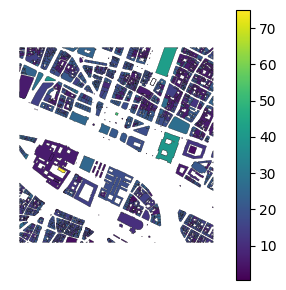

In [5]:
#@title OSM Download
from dateutil.relativedelta import relativedelta


bbox = saved_bbox


sim_date = date_picker.value or date.today()

# first_of_month  = sim_date.replace(day=1)
# last_prev_month = first_of_month - timedelta(days=1)
# first_prev_month = last_prev_month.replace(day=1)
# start_str = first_prev_month.strftime("%Y-%m-%d")
# end_str   = last_prev_month .strftime("%Y-%m-%d")



# three months prior to sim_date
start_date = sim_date - relativedelta(months=10)
# end at the day before sim_date
end_date   = sim_date - timedelta(days=1)
start_str  = start_date.strftime("%Y-%m-%d")
end_str    = end_date.strftime("%Y-%m-%d")

start_hr, end_hr = hours_slider.value
hours_list  = list(range(start_hr, end_hr+1))

outdir = Path("outputs")
outdir.mkdir(exist_ok=True)

# <<< build prefix from bbox min_lon (bbox[0]) and max_lat (bbox[3])
lon_str = f"{bbox[0]:.3f}".replace('.', 'p')
lat_str = f"{bbox[3]:.3f}".replace('.', 'p')
# prefix = f"{lon_str}_{lat_str}"
# <<< subfolder per‐tile
region_outdir = outdir / prefix
region_outdir.mkdir(parents=True, exist_ok=True)

template_tif = create_template_raster(bbox, resolution=1.0, dst=region_outdir / "template.tif")


# 1–4: OSM data & building shadows
_log.info("Running OSM & building shadows pipeline")
bld, streets = _download_osm(bbox)
bld = _clip_to_bbox(bld, bbox)
fps = _footpaths(streets)
bld3 = _enrich(bld)
# ── Preprocess for pybdshadow ────────────────────────────────────────────────
bld3 = pybdshadow.bd_preprocess(bld3, height="est_height_m")
bld3['height'] = bld3['est_height_m'].astype(float)

fig, ax = plt.subplots(figsize=(3, 3))
bld3.plot(
    ax=ax,
    column='height',            # color by building height
    cmap='viridis',             # you can choose any matplotlib colormap
    legend=True,                # show colorbar legend
    edgecolor='k',              # black outlines
    linewidth=0.2
)
# ax.set_title("Buildings (colored by ht)")
ax.set_axis_off()              # turn off axes for a cleaner look
plt.tight_layout()
plt.show()

bld3.to_file(region_outdir / f"{prefix}_buildings_3d.gpkg", driver="GPKG")
fps.to_file(region_outdir / f"{prefix}_footpaths.gpkg", driver="GPKG")



In [ ]:
#@title Earth Engine exports: canopy, NDVI

_log.info("Exporting canopy, NDVI & water mask via Earth Engine → Drive")

ee.Authenticate(); ee.Initialize(project="ee-deepankverma1")
region = ee.Geometry.Rectangle(bbox)

# canopy
ce = ee.ImageCollection("projects/meta-forest-monitoring-okw37/assets/CanopyHeight").mosaic()
t1 = ee.batch.Export.image.toDrive(
    image=ce.clip(region), description="export_canopy_1m",
    folder=folder, fileNamePrefix=f"{prefix}_canopy_1m",
    region=region.coordinates().getInfo(), scale=1,
    crs="EPSG:3857", maxPixels=1e13
)
# NDVI
s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterBounds(region)
      .filterDate(start_str, end_str)
      .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE",10))
      .median())
nd = s2.normalizedDifference(["B8","B4"]).rename("NDVI")


t2 = ee.batch.Export.image.toDrive(
    image=nd.clip(region), description="export_ndvi_10m",
    folder=folder, fileNamePrefix=f"{prefix}_ndvi_10m",
    region=region.coordinates().getInfo(), scale=10,
    crs="EPSG:3857", maxPixels=1e13
)
# worldcover water mask
t3 = _export_worldcover_water_to_drive(region, scale=10)
t1.start(); t2.start(); t3.start()
for t in (t1, t2, t3):
    _log.info("Polling %s …", t.status()["description"])
    while True:
        st = t.status()["state"]
        _log.info(" → %s", st)
        if st in ("COMPLETED","FAILED"): break
        time.sleep(120)

# 8. Mount & copy from Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
src_base = Path('/content/drive/My Drive')  / folder

export_fns = (
    "canopy_1m.tif",
    "ndvi_10m.tif",
    "water_mask.tif",
)


for fn in export_fns:
    src = src_base / f"{prefix}_{fn}"
    dst = region_outdir / f"{prefix}_{fn}"
    _log.info("Copying %s → %s", src, dst)
    shutil.copy(src, dst)


# plot canopy height
plot_raster(
    str(region_outdir / f"{prefix}_canopy_1m.tif"),
    # title="Canopy Height (m)",
    save_path=f"{prefix}_canopy_1m.jpg",
    cmap="viridis_r"
)

# plot NDVI
plot_raster(
    str(region_outdir / f"{prefix}_ndvi_10m.tif"),
    # title="NDVI",
    save_path=f"{prefix}_ndvi_10m.jpg",
    cmap="RdYlGn"
)

10:33:45 | INFO    | Exporting canopy, NDVI & water mask via Earth Engine → Drive
INFO:simcity:Exporting canopy, NDVI & water mask via Earth Engine → Drive
10:33:47 | INFO    | Polling export_canopy_1m …
INFO:simcity:Polling export_canopy_1m …
10:33:47 | INFO    |  → READY
INFO:simcity: → READY
10:35:47 | INFO    |  → READY
INFO:simcity: → READY
10:37:47 | INFO    |  → READY
INFO:simcity: → READY


In [ ]:
#@title Shadows-hourly



# 1) Build local‐midnight in the user’s timezone
start_local = _dt.datetime(
    sim_date.year,
    sim_date.month,
    sim_date.day,
    tzinfo=saved_tz
)

shadows_dir = region_outdir / "shadows"
shadows_dir.mkdir(parents=True, exist_ok=True)

# preload template metadata & shape
with rasterio.open(template_tif) as tmpl:
    tmpl_meta = tmpl.meta.copy()
    height, width = tmpl.height, tmpl.width

empty_mask = np.zeros((height, width), dtype="uint8")

# 3) Loop over each chosen hour, convert to UTC, then run shadow routines
for hour in hours_list:
    # local → UTC
    ts_local = start_local + timedelta(hours=hour)
    ts_local_str = ts_local.strftime("%Y%m%dT%H%M")
    ts_utc   = ts_local.astimezone(timezone.utc)
    ts_str   = ts_utc.strftime("%Y%m%dT%H%M")

    _log.info(f"Generating shadows for {ts_local.isoformat()} (local) → {ts_utc.isoformat()} (UTC)")

    # 3a) Building shadows
    bld_shadow_path = shadows_dir / f"{prefix}_shadow_buildings_{ts_str}.tif"
    try:
        sh_bld = _shadow_raster_pybdshadow(
            buildings    = bld3,
            time_utc     = ts_utc,
            template_tif = str(template_tif),
            dst          = bld_shadow_path
        )
    except ValueError:
        _log.info(f"  ↳ Sun down at local {ts_local.hour:02d}:00 → empty building mask")
        tmpl_meta.update(dtype="uint8", count=1)
        with rasterio.open(bld_shadow_path, "w", **tmpl_meta) as dst:
            dst.write(empty_mask, 1)
        sh_bld = bld_shadow_path

    # 3b) Tree shadows
    tree_shadow_path = shadows_dir / f"{prefix}_shadow_trees_{ts_str}.tif"
    try:
        sh_tree = _shadow_raster_trees_pybdshadow(
            canopy_tif   = str(region_outdir / f"{prefix}_canopy_1m.tif"),
            time_utc     = ts_utc,
            template_tif = str(template_tif),
            dst          = tree_shadow_path
        )
    except ValueError:
        _log.info(f"  ↳ Sun down at local {ts_local.hour:02d}:00 → empty tree mask")
        tmpl_meta.update(dtype="uint8", count=1)
        with rasterio.open(tree_shadow_path, "w", **tmpl_meta) as dst:
            dst.write(empty_mask, 1)
        sh_tree = tree_shadow_path

    # 4) (Optional) plot
    plot_raster(
        str(bld_shadow_path),
        save_path=f"{prefix}_Building_Shadow@{ts_str}.jpg",
        cmap="gray_r"
    )
    plot_raster(
        str(tree_shadow_path),
        save_path=f"{prefix}_Tree_Shadow@{ts_str}.jpg",
        cmap="gray_r"
    )

_log.info("✓ All hourly shadow maps generated in outputs/shadows/")




In [ ]:
#@title Veg/building/impervious/water masks

_log.info("Building vegetation mask")
veg_m = write_vegetation_mask(ndvi_tif=str(region_outdir / f"{prefix}_ndvi_10m.tif"),
                              threshold=0.3, dst=region_outdir / f"{prefix}_vegetation_mask.tif",
                              template_tif=str(template_tif))

plot_raster(str(veg_m),
            # title="Vegetation Mask",
            save_path=f"{prefix}_Vegetation Mask.jpg",
            cmap="Greens")

_log.info("Building footprint mask")
bld_m = write_building_mask(bld3, str(template_tif), region_outdir / f"{prefix}_building_mask.tif")

plot_raster(str(bld_m),
            # title="Building Footprint Mask",
            save_path=f"{prefix}_Building_Footprint_Mask.jpg",
            cmap="gray_r")

_log.info("Building water mask")
water_m = write_water_mask(str(region_outdir / f"{prefix}_water_mask.tif"),
    dst=region_outdir / f"{prefix}_water_mask.tif",
                        template_tif=str(template_tif))

plot_raster(str(water_m),
            # title="Water Mask",
            save_path=f"{prefix}_Water_Mask.jpg",
            cmap="Blues")

_log.info("Building impervious mask")
# imp_m = write_impervious_mask(str(veg_m), str(bld_m),
#                           region_outdir / f"{prefix}_impervious_mask.tif",
#                           template_tif=str(template_tif))
# plot_raster(str(imp_m), title="Impervious Surface Mask", cmap="gray")

imp_m = write_impervious_mask(
    veg_tif       = str(veg_m),
    bld_tif       = str(bld_m),
    water_tif     = str(water_m),
    canopy_tif    = str(region_outdir / f"{prefix}_canopy_1m.tif"),
    dst           = region_outdir / f"{prefix}_impervious_mask.tif",
    template_tif  = str(template_tif)
)
plot_raster(str(imp_m),
            # title="Impervious Mask",
            save_path=f"{prefix}_Impervious_Mask_.jpg",
            cmap="gray_r")


# 12: Surface albedo map
_log.info("Building surface albedo map")
alb_map = write_albedo_map(
    veg_mask_tif=str(veg_m),
    bld_mask_tif=str(bld_m),
    imp_mask_tif=str(imp_m),
    water_mask_tif=str(water_m),
    out_tif=str(region_outdir / f"{prefix}_surface_albedo.tif"),
    values={'veg': 0.25,  'bld': 0.22, 'imp': 0.15, 'water': 0.05}
)

plot_raster(str(alb_map),
            save_path=f"{prefix}_Albedo_Mask_.jpg",
            cmap="inferno")

_log.info("Albedo raster written to %s", alb_map)

_log.info("All done! Outputs in %s", outdir.resolve())

In [ ]:
#@title 30m DEM and DSM Download

region = ee.Geometry.Rectangle(*bbox)

# ── Export DEM (SRTM 30 m) ─────────────────────────────────────────────────────
dem = ee.Image("USGS/SRTMGL1_003")                              # NASA SRTM V3 (~30 m)
task_dem = ee.batch.Export.image.toDrive(
    image=dem.select("elevation").clip(region),                 # Elevation band
    description="export_dem_30m",
    folder=folder,
    fileNamePrefix=f"{prefix}_dem_30m",
    region=region.coordinates().getInfo(),
    scale=30,                                                    # 30 m resolution
    crs="EPSG:3857",                                             # Match your pipeline CRS
    maxPixels=1e13                                               # Allow large export
)


# ── Export DSM (ALOS AW3D30 30 m) ─────────────────────────────────────────────
alos = ee.ImageCollection("JAXA/ALOS/AW3D30/V4_1")               # ALOS AW3D30 DSM (~30 m)
dsm = alos.mosaic().select("DSM").clip(region)                  # Mosaic collection to single image
task_dsm = ee.batch.Export.image.toDrive(
    image=dsm,
    description="export_dsm_30m",
    folder=folder,
    fileNamePrefix=f"{prefix}_dsm_30m",
    region=region.coordinates().getInfo(),
    scale=30,                                                    # 30 m resolution
    crs="EPSG:3857",                                             # Consistent CRS
    maxPixels=1e13                                               # Allow large export
)


# ── Start & Poll Tasks ────────────────────────────────────────────────────────
task_dem.start(); task_dsm.start()
for task in (task_dem, task_dsm):
    print(f"Polling {task.status()['description']} …")
    while True:
        state = task.status()["state"]
        print(" →", state)
        if state in ("COMPLETED", "FAILED"):
            break
        time.sleep(30)


# 3. Polling & copy function
def wait_and_copy(filename, max_attempts=20, interval=30):
    src = src_base / filename
    dst = region_outdir / filename

    attempts = 0
    # Loop until file exists
    while not src.exists():  # pathlib.Path.exists()
        if attempts >= max_attempts:
            # Try flushing cache and remounting if still missing
            from google.colab import drive as gdrive
            gdrive.flush_and_unmount()  # Flush local cache to Drive
            drive.mount('/content/drive', force_remount=True)
            attempts = 0
        print(f"Waiting for {filename} (attempt {attempts + 1})…")
        time.sleep(interval)       # pause between checks
        attempts += 1

    # Once present, ensure it's a file
    if not os.path.isfile(src):   # os.path.isfile() check
        raise FileNotFoundError(f"{filename} exists but is not a file.")

    # Copy to outputs
    shutil.copy(str(src), str(dst))  # shutil.copy()
    print(f"✓ Copied {filename} → {dst}")

# 4. Apply to both DEM & DSM
for fname in (f"{prefix}_dem_30m.tif", f"{prefix}_dsm_30m.tif"):
    wait_and_copy(fname)

    # 5. Align DEM & DSM to the template raster
_log.info("Aligning DEM and DSM to the template raster")

dem_aligned = clip_raster_to_template(
    src_tif=str(region_outdir / f"{prefix}_dem_30m.tif"),
    template_tif=str(region_outdir / "template.tif"),
    dst_tif=str(region_outdir / f"{prefix}_dem_30m_aligned.tif")
)

dsm_aligned = clip_raster_to_template(
    src_tif=str(region_outdir / f"{prefix}_dsm_30m.tif"),
    template_tif=str(region_outdir / "template.tif"),
    dst_tif=str(region_outdir / f"{prefix}_dsm_30m_aligned.tif")
)

# ── Plot aligned DEM & DSM ────────────────────────────────────────────────────
plot_raster(
    str(dem_aligned),
    # title="DEM 30m (aligned)",
    save_path=f"{prefix}_DEM_30m.jpg",
    cmap="terrain"
)
plot_raster(
    str(dsm_aligned),
    # title="DSM 30m (aligned)",
    save_path=f"{prefix}_DSM_30m.jpg",
    cmap="terrain"
)

_log.info("✓ DEM and DSM aligned and written to outputs/")


In [ ]:
#@title 1m DSM and SVF

Path("outputs").mkdir(exist_ok=True)
region_outdir.mkdir(exist_ok=True)

dem30_path     = region_outdir / f"{prefix}_dem_30m_aligned.tif"
bld_gpkg_path  = region_outdir / f"{prefix}_buildings_3d.gpkg"
canopy1m_path  = region_outdir / f"{prefix}_canopy_1m.tif"

dsm1m_path     = region_outdir / f"{prefix}_dsm_1m.tif"
svf1m_path     = region_outdir / f"{prefix}_svf_1m.tif"
svf30m_path    = region_outdir / f"{prefix}_svf_30m.tif"

# ── 4. Load & upsample DEM to 1 m ────────────────────────────────────────
with rasterio.open(dem30_path) as src:
    dem30     = src.read(1, masked=True).filled(np.nan).astype(np.float32)
    prof30    = src.profile
    crs       = src.crs
    tr30      = src.transform

# compute new 1 m transform and shape
from rasterio.transform import Affine
xres30, yres30 = prof30["transform"][0], prof30["transform"][4]
width30, height30 = prof30["width"], prof30["height"]
width1  = int(abs(xres30 * width30)  / 1)
height1 = int(abs(yres30 * height30) / 1)
tr1     = Affine(1, 0, tr30.c, 0, -1, tr30.f)


# # 2) Lightly smooth to remove step artifacts
dem30_smooth = gaussian_filter(dem30, sigma=4.0)

dem1 = np.empty((height1, width1), dtype=np.float32)
reproject(
    source       = dem30_smooth,
    destination  = dem1,
    src_transform= tr30,
    src_crs      = crs,
    dst_transform= tr1,
    dst_crs      = crs,
    resampling   = Resampling.lanczos  ## smoothing
)



# ── 5. Rasterize building heights at 1 m ─────────────────────────────────
gdf = gpd.read_file(bld_gpkg_path).to_crs(crs)
shapes = ((geom, float(h)) for geom, h in zip(gdf.geometry, gdf["est_height_m"]))
bld1 = rasterize(
    shapes     = shapes,
    out_shape  = dem1.shape,
    transform  = tr1,
    fill       = 0,
    dtype      = np.float32
)

# ── 6. Reproject canopy to 1 m grid (max) ────────────────────────────────
with rasterio.open(canopy1m_path) as src:
    canopy_src = src.read(1, masked=True).filled(0).astype(np.float32)
    tr_canopy  = src.transform
    crs_canopy = src.crs

canopy1 = np.zeros_like(dem1, dtype=np.float32)
reproject(
    source       = canopy_src,
    destination  = canopy1,
    src_transform= tr_canopy,
    src_crs      = crs_canopy,
    dst_transform= tr1,
    dst_crs      = crs,
    resampling   = Resampling.max
)

# ── 7. Build 1 m DSM & save ───────────────────────────────────────────────
dsm1 = dem1 + np.maximum(bld1, canopy1)
dsm1 = dsm1.astype(np.double)
prof1 = prof30.copy()
prof1.update({
    "dtype": rasterio.float32,
    "height": dem1.shape[0],
    "width": dem1.shape[1],
    "transform": tr1,
    "nodata": np.nan,
})
with rasterio.open(dsm1m_path, "w", **prof1) as dst:
    dst.write(dsm1, 1)


# plot the 1 m DSM in a terrain colormap
plot_raster(
    str(dsm1m_path),
    # title="DSM @ 1 m resolution",
    save_path=f"{prefix}_DSM_1m.jpg",
    cmap="terrain"
)

print("✓ Wrote 1 m DSM to", dsm1m_path)

# ── 8. Compute SVF @ 1 m & save ───────────────────────────────────────────
spacing = np.double(1.0)
svf1, _ = viewf(dsm1, spacing=spacing)
with rasterio.open(svf1m_path, 'w', **prof1) as dst:
    dst.write(svf1.astype(np.float32), 1)

# plot the 1 m SVF (sky‐view factor)
plot_raster(
    str(svf1m_path),
    # title="SVF @ 1 m resolution",
    save_path=f"{prefix}_SVF_1m.jpg",
    cmap="viridis"
)


print("✓ SVF computed and written to ", svf1m_path)




In [ ]:
#@title Atmosphere, Turbidity & Irradiance Pipeline


outdir = region_outdir                                    # existing folder with your masks & SVF
irradiance_dir = outdir / "irradiance_maps"
irradiance_dir.mkdir(parents=True, exist_ok=True)

# 2.1 Compute site center from bbox
min_lon, min_lat, max_lon, max_lat = bbox
lon = (min_lon + max_lon) / 2.0
lat = (min_lat + max_lat) / 2.0

# 0. Determine a valid request date
today = datetime.utcnow().date()
req_date = sim_date if sim_date <= today - timedelta(days=1) else today - timedelta(days=1)
# if req_date > today - timedelta(days=1):
#     req_date = today - timedelta(days=1)
user_date_str = req_date.strftime("%Y%m%d")
print("→ Requesting POWER for date:", user_date_str)

# 3. C1: Daily API – AOD_55, TQV, TO3 retrieval
daily_url = "https://power.larc.nasa.gov/api/temporal/daily/point"  # Daily endpoint
daily_params = {
    'latitude'      : lat,
    'longitude'     : lon,
    'start'         : user_date_str,
    'end'           : user_date_str,
    'community'     : 'RE',
    'format'        : 'JSON',
    'time-standard' : 'UTC',
    'parameters'    : 'AOD_55,TQV,TO3'  # correct Daily API names
}
r = requests.get(daily_url, params=daily_params)
print("DAILY STATUS:", r.status_code, "KEYS:", list(r.json().keys()))
print("DAILY MESSAGES:", r.json().get("messages"))
r.raise_for_status()
resp = r.json()['properties']['parameter']

print("resp from daily api", resp)

# 2. If empty, fallback to climatology (typical day)
aod_val = resp['AOD_55'].get(user_date_str, None)
if aod_val is None or aod_val < 0 or pd.isna(aod_val):
    print(f" No daily data for {user_date_str} — attempting climatology fallback")
    clim_url = "https://power.larc.nasa.gov/api/temporal/climatology/daily/point"
    clim_params = daily_params.copy()
    clim_params.pop('start', None)
    clim_params.pop('end', None)

    try:
        r2 = requests.get(clim_url, params=clim_params)
        r2.raise_for_status()
        prop = r2.json()['properties']['parameter']
        mon_abbr = sim_date.strftime("%b").upper()  # e.g. "MAY"
        resp = {
            'AOD_55': {user_date_str: prop['AOD_55'][mon_abbr]},
            'TQV'   : {user_date_str: prop['TQV'][mon_abbr]},
            'TO3'   : {user_date_str: prop['TO3'][mon_abbr]},
        }
        print(" → Got climatology:", resp['AOD_55'][user_date_str])
    except Exception as e:
        print(" Climatology unavailable, using default AOD_55 = 0.1:", e)
        resp['AOD_55'] = {user_date_str: 0.1}

# 3. Build your atm DataFrame exactly as before…
dt = pd.to_datetime(user_date_str, format='%Y%m%d')
atm = pd.DataFrame({
    'aod550': [resp['AOD_55'][user_date_str]],
    'pwvap' : [resp['TQV'][user_date_str]],
    'ozone' : [resp['TO3'][user_date_str]],
}, index=[dt])
print(atm)

# 4. C2: Compute Linke turbidity
# 4.1 Site pressure from DEM mean elevation

dem30_path = outdir / f"{prefix}_dem_30m_aligned.tif"
with rasterio.open(dem30_path) as src:
    altitude = float(src.read(1).mean())
pressure = alt2pres(altitude)

# 4.2 Solar position & airmass 4.3 Linke turbidity



start_local = datetime(sim_date.year, sim_date.month, sim_date.day, tzinfo=saved_tz)
noon_local  = start_local + timedelta(hours=12)
solnoon     = pvlib.solarposition.get_solarposition(noon_local, lat, lon)

am_rel_noon = get_relative_airmass(solnoon['apparent_zenith'])            # returns a number
am_abs_noon = get_absolute_airmass(am_rel_noon, pressure)                # pressure‐adjusted
# now compute a single turbidity value
turbidity_noon = kasten96_lt(am_abs_noon, atm['pwvap'].iloc[0], atm['aod550'].iloc[0])
# broadcast it across the day if you need an hourly series
atm['turbidity'] = turbidity_noon[0]

print("solpos", solnoon)
print("am_abs", am_abs_noon)



# print("atm_with_turbidity", atm)

# 5. D: Hourly GHI/DNI/DHI retrieval (tz-naive index)
hourly_url = "https://power.larc.nasa.gov/api/temporal/hourly/point"
hourly_params = {
    'latitude': lat, 'longitude': lon,
    'start': user_date_str, 'end': user_date_str,
    'community': 'RE','format': 'JSON',
    'time-standard': 'UTC',
    # correct hourly shortwave parameters
    'parameters': 'ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DIFF,T2M'
}

resp2 = requests.get(hourly_url, params=hourly_params)
resp2.raise_for_status()
data2 = resp2.json()['properties']['parameter']

print("Hourly keys:", list(data2.keys()))



times_utc = pd.to_datetime(list(data2['ALLSKY_SFC_SW_DWN'] .keys()),
                            format='%Y%m%d%H', utc=True)

 # remove index = times, nan was being thrown


##### this project uses clear sky ##########
ghi = pd.Series(data2['ALLSKY_SFC_SW_DWN'], index=times_utc).astype(float)
dni = pd.Series(data2['ALLSKY_SFC_SW_DNI'], index=times_utc).astype(float)
dhi = pd.Series(data2['ALLSKY_SFC_SW_DIFF'],index=times_utc).astype(float)

# 2) Convert to local for filtering
times_local = times_utc.tz_convert(saved_tz)

# 6. E: Compute clear-sky using the SAME tz-naive index
# First, compute hourly airmass (pressure from DEM as before)
dni_extra  = pvlib.irradiance.get_extra_radiation(times_utc)
solpos_utc = pvlib.solarposition.get_solarposition(times_utc, lat, lon)
am_rel     = get_relative_airmass(solpos_utc['apparent_zenith'])
am_abs     = get_absolute_airmass(am_rel, pressure)

# Repeat daily turbidity across hours
turbidity_hourly = pd.Series(atm['turbidity'].iloc[0], index=times_utc)

# Clear-sky model
cs = ineichen(
    solpos_utc['apparent_zenith'],
    am_abs,
    turbidity_hourly,
    altitude=altitude,
    dni_extra=dni_extra
)
# 7. F: Load & combine shadows, SVF, albedo

# 7.1 Open the 1 m reference grid (building shadows)
with rasterio.open(outdir / f"{prefix}_dsm_1m.tif") as ref:
    ref_transform = ref.transform
    ref_crs       = ref.crs
    ref_h, ref_w  = ref.height, ref.width
    ref_meta      = ref.meta.copy()


def reproject_to_ref(src_fp, resampling=Resampling.bilinear, dtype=np.float32):
    """Reproject a single-band raster to the 1 m reference grid."""
    with rasterio.open(src_fp) as src:
        dst = np.zeros((ref_h, ref_w), dtype=dtype)
        reproject(
            source        = src.read(1),
            src_transform = src.transform,
            src_crs       = src.crs,
            dst_transform = ref_transform,
            dst_crs       = ref_crs,
            dst_shape     = (ref_h, ref_w),
            resampling    = resampling,
            destination   = dst
        )
    return dst



svf_path = outdir / f"{prefix}_svf_1m.tif"
svf      = reproject_to_ref(svf_path,
                            resampling=Resampling.bilinear)

albedo_path = outdir / f"{prefix}_surface_albedo.tif"
albedo   = reproject_to_ref(albedo_path,
                            resampling=Resampling.bilinear)




for power_ts_utc, ts_loc in zip(times_utc, times_local):
    if ts_loc.hour not in hours_list:
        continue


    # 1) This is for irradiance/POWER lookups:
    power_ts_str = power_ts_utc.strftime('%Y%m%dT%H%M')

    # 2) For shadow files, rebuild from local-midnight + hour:
    hour = ts_loc.hour
    ts_shadow_local = start_local + timedelta(hours=hour)
    ts_shadow_utc   = ts_shadow_local.astimezone(timezone.utc)
    shadow_ts_str   = ts_shadow_utc.strftime("%Y%m%dT%H%M")


    print(f"→ Computing irradiance @ {power_ts_str}, loading shadows @ {shadow_ts_str}")

    # 1) load + reproject this hour's building shadow
    bld_fp = outdir / "shadows" / f"{prefix}_shadow_buildings_{shadow_ts_str}.tif"
    sh_bld = reproject_to_ref(
        bld_fp,
        resampling=Resampling.nearest,
        dtype=np.uint8
    ).astype(bool)

    # 2) load + reproject this hour's tree shadow
    tree_fp = outdir / "shadows" / f"{prefix}_shadow_trees_{shadow_ts_str}.tif"
    sh_tree = reproject_to_ref(
        tree_fp,
        resampling=Resampling.nearest,
        dtype=np.uint8
    ).astype(bool)

    # 3) build masks (direct beam transmission)
    # shadow = sh_bld | sh_tree                 # boolean mask
    # bm     = 1.0 - shadow.astype(float)       # 1 in sun, 0 in shade

    ####################################
        # --- Parameters for tree transmissivity (tune if needed) ---
        # 1) Infer site latitude from your bbox-derived 'lat'
    site_lat = float(lat)

    # 2) Use the simulation date for phenology (not the POWER request date)
    try:
        # sim_date is a datetime.date in your notebook
        current_date = sim_date
    except Exception:
        # if sim_date happened to be a datetime, take the date part
        from datetime import date as _date
        current_date = _date(sim_date.year, sim_date.month, sim_date.day)

    # 3) Choose vegetation profile ("deciduous" or "evergreen")
    veg_profile = "deciduous"  # change to "evergreen" if applicable

    # Choose deciduous by default; change to "evergreen" if your city is evergreen.
    TAU_DIR, TAU_DIF = tree_transmissivity_for_date(current_date, site_lat, profile=veg_profile)
    print(f"[trees] {current_date} @ lat {site_lat:+.4f} → tau_dir={TAU_DIR:.2f}, tau_dif={TAU_DIF:.2f}")

    # 1) building mask (opaque)
    bm_bld = 1.0 - sh_bld.astype(float)  # 0 where building shade, 1 otherwise

    # 2) tree mask (semi-opaque) — include both cast shadow AND crown footprint
    canopy_mask = reproject_to_ref(
        outdir / f"{prefix}_canopy_1m.tif",
        resampling=Resampling.nearest,
        dtype=np.uint8
    ) > 0

    sh_tree_any = (sh_tree | canopy_mask).astype(float)  # anything under crown or its cast shadow
    bm_tree     = 1.0 - (1.0 - TAU_DIR) * sh_tree_any    # 1 in sun, tau_dir under trees

    # 3) combined direct-beam transmission (buildings still dominate)
    bm = bm_bld * bm_tree   # 0 in building shade; tau_dir in tree shade; 1 in sun

#############################################

    # 4) pull clear-sky irradiances (scalars for this timestamp)
    dni_cs = float(cs.loc[power_ts_utc, 'dni'])
    dhi_cs = float(cs.loc[power_ts_utc, 'dhi'])
    ghi_cs = float(cs.loc[power_ts_utc, 'ghi'])  # not using in the notebook in the current two-band shortwave (direct + diffuse) setup

    # 5) compute per-pixel components (no SVF applied here)
    solzen_deg = float(solpos_utc.loc[power_ts_utc, 'apparent_zenith'])
    cosZ       = np.cos(np.deg2rad(solzen_deg))

    E_dir = dni_cs * bm * cosZ                       # Band 1: direct, shadow-masked
    E_dif = np.full_like(E_dir, dhi_cs, dtype=np.float32)   # Band 2: diffuse, UNWEIGHTED

    # 6) write 2-band GeoTIFF
    out_meta = ref_meta.copy()
    out_meta.update(dtype='float32', count=2, compress='lzw', nodata=None)

    out_fp = irradiance_dir / f"{prefix}_irr_{shadow_ts_str}.tif"
    with rasterio.open(out_fp, 'w', **out_meta) as dst:
        dst.write(E_dir.astype(np.float32), 1)   # Band 1
        dst.write(E_dif.astype(np.float32), 2)   # Band 2

    print(f"   ↳ wrote {out_fp}")

    # Quicklook: this will display Band 1 (direct) by default
    plot_raster(
        str(out_fp),
        # title=f"Irradiance (Band 1: Direct) @ {shadow_ts_str} (W/m²)",
        save_path=f"{prefix}_Irradiance_DIR_@_{shadow_ts_str}.jpg",
        cmap="inferno"
    )


############################ export tree shade with transmissivity #############

# --- NEW: export tree shade with transmissivity for this hour ---

    # 1) Direct-beam *transmittance* under trees (1 in sun; tau_dir in tree/crown shade)
    tree_tau_meta = ref_meta.copy()
    tree_tau_meta.update(dtype='float32', count=1, compress='lzw', nodata=None)

    tree_tau_fp = irradiance_dir / f"{prefix}_tree_beam_transmittance_{shadow_ts_str}.tif"
    with rasterio.open(tree_tau_fp, 'w', **tree_tau_meta) as dst:
        dst.write(bm_tree.astype(np.float32), 1)

    plot_raster(
    str(tree_tau_fp),
    save_path=f"{prefix}_Quicklook_tree_beam_transmittance_{shadow_ts_str}.jpg",
    cmap="gray"
    )


print("✓ All hourly irradiance maps written.")



In [ ]:
#@title MRT Generation


# 0) Air temperature series (K)
t2m = pd.Series(data2['T2M'])
t2m.index = pd.to_datetime(t2m.index, format='%Y%m%d%H', utc=True)
t2m = t2m.sort_index()

# 1) Output folder
mrt_dir = region_outdir / "mrt_maps"
os.makedirs(mrt_dir, exist_ok=True)

# 2) Constants (reuse yours if already defined above)
sigma      = 5.67e-8   # W m-2 K-4
eps_sky    = 0.90
eps_ground = 0.95
eps_globe  = 1.00

# 3) Irradiance rasters (written by your new 2-band writer)
irr_dir   = region_outdir / "irradiance_maps"
irr_files = sorted(glob.glob(str(irr_dir / f"{prefix}_irr_*.tif")))
if not irr_files:
    raise RuntimeError(f"No irradiance files found in {irr_dir}")

# 4) Base metadata from first file
with rasterio.open(irr_files[0]) as src0:
    mrt_meta = src0.meta.copy()
mrt_meta.update(dtype='float32', count=1, nodata=None, compress='lzw')

# 5) Load SVF once
svf_fp = outdir / f"{prefix}_svf_1m.tif"
if not svf_fp.exists():
    raise FileNotFoundError(f"SVF raster not found: {svf_fp}")

with rasterio.open(svf_fp) as svf_src:
    svf_full    = svf_src.read(1).astype(np.float32)
    svf_profile = svf_src.profile

def _resample_to(match_src, arr, arr_profile):
    """Resample 'arr' (in arr_profile georeference) to match match_src grid."""
    out = np.empty((match_src.height, match_src.width), dtype=np.float32)
    reproject(
        source=arr,
        destination=out,
        src_transform=arr_profile['transform'],
        src_crs=arr_profile['crs'],
        dst_transform=match_src.transform,
        dst_crs=match_src.crs,
        resampling=Resampling.bilinear,
    )
    return out

# 6) Loop over irradiance timestamps
for irr_fp in irr_files:
    fn            = os.path.basename(irr_fp)
    ts_str        = fn.replace(f"{prefix}_irr_", "").replace(".tif", "")
    ts_utc        = pd.to_datetime(ts_str, format="%Y%m%dT%H%M", utc=True)
    ts_loc        = ts_utc.tz_convert(saved_tz)

    # Honor your hour filter if provided
    if hours_list and (ts_loc.hour not in hours_list):
        continue

    # Align temperature (snap to hour; nearest-hour fallback if missing)
    temp_key = ts_utc.floor('H')
    if temp_key not in t2m.index:
        idx = t2m.index.get_indexer([temp_key], method='nearest')[0]
        temp_key = t2m.index[idx]
    T_air_K = float(t2m.loc[temp_key]) + 273.15

    with rasterio.open(irr_fp) as src:
        # Ensure SVF matches grid
        if (svf_profile['transform'] != src.transform) or (svf_full.shape != (src.height, src.width)):
            svf = _resample_to(src, svf_full, svf_profile)
        else:
            svf = svf_full

        if src.count < 2:
            warnings.warn(f"{fn}: expected 2 bands (direct, diffuse). Found {src.count}. "
                          "Proceeding by treating band 1 as total SW (less accurate).")
            E_dir = src.read(1).astype(np.float32)
            E_dif = np.zeros_like(E_dir, dtype=np.float32)
        else:
            # Band 1: direct (already shadow-masked); Band 2: diffuse (UNWEIGHTED)
            E_dir = src.read(1).astype(np.float32)
            E_dif = src.read(2).astype(np.float32)

    ##############################
    # Canopy mask on this grid (align it like you do with SVF)
    # canopy_mask = _resample_to(src, (canopy_full > 0).astype(np.float32), canopy_profile) \
    #               if 'canopy_full' in globals() else None

    if canopy_mask is not None:
        # Effective SVF under crowns using seasonal TAU_DIF
        svf_eff = svf * (1.0 - (1.0 - TAU_DIF) * canopy_mask)
    else:
        svf_eff = svf

    # quick proxy for reflected shortwave reaching a person
    E_ref = albedo * (E_dir + E_dif) * (1.0 - svf_eff)   # use ~ground/walls view via (1 - SVF)

    # Shortwave total (use svf_eff for diffuse)
    E_sw = E_dir + svf_eff * E_dif + E_ref

    # also use svf_eff for longwave sky view
    E_lw_sky    = svf_eff * eps_sky    * sigma * (T_air_K**4)
    E_lw_ground = (1.0 - svf_eff) * eps_ground * sigma * (T_air_K**4)

    E_tot   = E_sw + E_lw_sky + E_lw_ground
    T_mrt_C = (E_tot / (sigma * 1.0))**0.25 - 273.15




    ##############################

    # # Shortwave with SVF on diffuse
    # E_sw = E_dir + svf * E_dif

    # # Longwave with SVF weighting
    # E_lw_sky    = svf * eps_sky    * sigma * (T_air_K ** 4)
    # E_lw_ground = (1.0 - svf) * eps_ground * sigma * (T_air_K ** 4)

    # # Total flux & MRT
    # E_total = E_sw + E_lw_sky + E_lw_ground
    # T_mrt_K = (E_total / (sigma * eps_globe)) ** 0.25
    # T_mrt_C = T_mrt_K - 273.15

    # Write MRT GeoTIFF
    out_fp = mrt_dir / f"{prefix}_mrt_{ts_str}.tif"
    with rasterio.open(out_fp, 'w', **mrt_meta) as dst:
        dst.write(T_mrt_C.astype('float32'), 1)

    # Optional quicklook
    plot_raster(
        str(out_fp),
        # title=f"MRT @ {ts_str} (°C)",
        save_path=f"{prefix}_MRT@{ts_str}.jpg",
        cmap="viridis"
    )
    print(f"→ Wrote {out_fp}")

print("✓ All hourly MRT maps generated (SVF-aware, using 2-band irradiance).")


In [ ]:
#@title Equal PMV implementation

# --- PET utils: equal-PMV PET via vectorized bisection ------------------------
# If available in your environment, install pythermalcomfort for PMV
# (in Colab uncomment):
# !pip install -q pythermalcomfort

# import numpy as np

try:
    from pythermalcomfort.models import pmv as _pmv_iso
except Exception:
    _pmv_iso = None

def _pmv_iso_numpy(tdb, tr, vr, rh, met, clo):
    """
    Thin wrapper over pythermalcomfort.pmv that accepts numpy arrays and returns numpy arrays.
    Falls back to a minimal ISO 7730 PMV implementation if pythermalcomfort is unavailable.
    Inputs in SI / typical thermal comfort units: tdb,tr [°C], vr [m/s], rh [%], met [met], clo [clo].
    """
    if _pmv_iso is not None:
        # vectorize library PMV for arrays
        vec = np.vectorize(lambda _tdb,_tr,_vr,_rh: _pmv_iso(tdb=float(_tdb), tr=float(_tr),
                                                            vr=float(_vr), rh=float(_rh),
                                                            met=float(met), clo=float(clo),
                                                            standard="ISO"))
        return vec(tdb, tr, vr, rh).astype(np.float32)

    # ---- minimal PMV fallback (ISO 7730), vectorized ----
    # References: ISO 7730 / Fanger. This is a compact implementation good enough for PMV matching.
    tdb = np.asarray(tdb, dtype=np.float64)
    tr  = np.asarray(tr,  dtype=np.float64)
    vr  = np.asarray(vr,  dtype=np.float64)
    rh  = np.asarray(rh,  dtype=np.float64)

    M   = met * 58.15          # W/m²
    W   = 0.0                  # W/m²
    Icl = clo                  # clo
    Icl_r = 0.155 * Icl        # m²·K/W

    # clothing area factor f_cl (piecewise per ISO)
    f_cl = np.where(Icl <= 0.5, 1.0 + 0.2*Icl, 1.05 + 0.645*Icl)

    # water vapor partial pressure [Pa] (Magnus)
    pa = (rh/100.0)*610.94*np.exp((17.625*tdb)/(tdb+243.04))

    # heat transfer coefficient (forced)
    hcf = 12.1*np.sqrt(np.maximum(vr, 0.0))

    # initial clothing surface temp [°C]
    tcla = tdb + (35.5 - tdb)/(3.5*(Icl_r + 0.1))

    # iterate T_clo (ISO)
    tcl = tcla.copy()
    for _ in range(50):
        # radiative heat transfer coefficient hr [W/m²K]
        hr = 4.0*5.67e-8 * f_cl * ((tcl+273.15 + tr+273.15)/2.0)**3
        # convective coefficient hc [W/m²K]
        hcn = 2.38*np.abs(tcl - tdb)**0.25
        hc  = np.maximum(hcf, hcn)
        # update T_cl
        num = (35.7 - 0.028*(M - W)) + ( (hr*(tr - tcl)) + (hc*(tdb - tcl)) )*Icl_r*f_cl
        den = 1.0 + Icl_r*f_cl*(hr + hc)
        tcl_new = num/den
        if np.all(np.abs(tcl_new - tcl) < 1e-3):
            tcl = tcl_new
            break
        tcl = tcl_new

    # heat losses (ISO forms)
    # NOTE: coefficients as in ISO 7730
    hl1 = 3.05*(5.733 - 0.007*(M - W) - pa/1000.0)                    # skin diffusion (W/m²)
    hl2 = np.where(M - W > 58.15, 0.42*((M - W) - 58.15), 0.0)        # sweat (W/m²)
    hl3 = 1.7e-5*M*(5867.0 - pa)                                      # latent respiration (W/m²)
    hl4 = 0.0014*M*(34.0 - tdb)                                       # dry respiration (W/m²)
    hl5 = 3.96e-8 * f_cl * ( (tcl+273.15)**4 - (tr+273.15)**4 )       # radiation (W/m²)
    # Use hc from last iteration:
    hcf_final = 12.1*np.sqrt(np.maximum(vr, 0.0))
    hcn_final = 2.38*np.abs(tcl - tdb)**0.25
    hc_final  = np.maximum(hcf_final, hcn_final)
    hl6 = f_cl*hc_final*(tcl - tdb)                                   # convection (W/m²)

    # PMV (ISO 7730)
    PMV = (0.303*np.exp(-0.036*M) + 0.028) * ((M - W) - (hl1 + hl2 + hl3 + hl4 + hl5 + hl6))
    return PMV.astype(np.float32)

def pet_equal_pmv(Ta_C, Tmrt_C, U_ms, RH_pct, met=2.3, clo=0.7,
                  ref_v=0.1, ref_rh=50.0, tmin=-20.0, tmax=60.0, iters=18):
    """
    Compute PET [°C] by finding T_ref such that PMV_ref(T_ref, Tr=T_ref, v=ref_v, RH=ref_rh)
    equals PMV_outdoor(Ta, Tr=Tmrt, v=U, RH), using bisection. Fully vectorized.
    """
    Ta  = np.asarray(Ta_C,   dtype=np.float32)
    Tr  = np.asarray(Tmrt_C, dtype=np.float32)
    U   = np.asarray(U_ms,   dtype=np.float32)
    RH  = np.asarray(RH_pct, dtype=np.float32)

    # target PMV in outdoor conditions
    pmv_target = _pmv_iso_numpy(Ta, Tr, U, RH, met=met, clo=clo)

    # bounds for Ta_ref in reference env
    lo = np.full_like(Ta, tmin, dtype=np.float32)
    hi = np.full_like(Ta, tmax, dtype=np.float32)

    # helper to get PMV in reference env at a given Ta_ref
    def pmv_ref(Tref):
        return _pmv_iso_numpy(Tref, Tref, np.full_like(U, ref_v), np.full_like(RH, ref_rh),
                              met=met, clo=clo)

    pmv_lo = pmv_ref(lo)
    pmv_hi = pmv_ref(hi)

    # ensure monotonic (PMV increases with T), swap where needed
    swap = pmv_lo > pmv_hi
    lo[swap], hi[swap] = hi[swap], lo[swap]
    pmv_lo, pmv_hi = np.minimum(pmv_lo, pmv_hi), np.maximum(pmv_lo, pmv_hi)

    # clamp target PMV to bracket if outside (avoids NaN PET at extremes)
    pmv_target = np.clip(pmv_target, pmv_lo, pmv_hi)

    # bisection
    for _ in range(iters):
        mid = (lo + hi) * 0.5
        pmv_mid = pmv_ref(mid)
        go_hi = pmv_mid < pmv_target
        lo = np.where(go_hi, mid, lo)
        hi = np.where(go_hi, hi, mid)

    PET = (lo + hi) * 0.5
    return PET.astype(np.float32)


In [ ]:
#@title  Build hourly TaC / RH / U1p1 rasters from NASA POWER
# Output filenames: {prefix}_TaC_{YYYYMMDDTHHMM}.tif, {prefix}_RH_{...}.tif, {prefix}_U1p1_{...}.tif
# Writes into: region_outdir / "meteo"

# import os, glob, requests
# import numpy as np
# import pandas as pd
# import rasterio
# from rasterio.warp import Resampling, reproject

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


met_dir = region_outdir / "meteo"
met_dir.mkdir(parents=True, exist_ok=True)

# 0) Collect timestamps from your MRT rasters (UTC)
mrt_dir = region_outdir / "mrt_maps"
mrt_files = sorted(glob.glob(str(mrt_dir / f"{prefix}_mrt_*.tif")))
if not mrt_files:
    raise RuntimeError("No MRT rasters found. Generate MRT first so we can mirror its timestamps.")

ts_list = []
for fp in mrt_files:
    ts_str = os.path.basename(fp).replace(f"{prefix}_mrt_", "").replace(".tif", "")
    ts_list.append(pd.to_datetime(ts_str, format="%Y%m%dT%H%M", utc=True))
ts_list = sorted(ts_list)
start_ymd = ts_list[0].strftime("%Y%m%d")
end_ymd   = ts_list[-1].strftime("%Y%m%d")

# 1) Get AOI center (lat/lon WGS84) from the first MRT GeoTIFF
with rasterio.open(mrt_files[0]) as ref:
    H, W  = ref.height, ref.width
    tfm   = ref.transform
    crs   = ref.crs
    cy, cx = H // 2, W // 2
    x0, y0 = xy(tfm, cy, cx)
    if crs and crs.to_string() not in ("EPSG:4326", "WGS84"):
        transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
        lon, lat = transformer.transform(x0, y0)
    else:
        lon, lat = x0, y0
lat = float(lat); lon = float(lon)

# 2) Fetch NASA POWER hourly (UTC) for the date span
params = ["T2M","RH2M","WS10M"]
url = (
    "https://power.larc.nasa.gov/api/temporal/hourly/point"
    f"?latitude={lat:.6f}&longitude={lon:.6f}"
    f"&start={start_ymd}&end={end_ymd}"
    f"&parameters={','.join(params)}&community=ag&format=JSON&time-standard=UTC"
)
resp = requests.get(url, timeout=60)
resp.raise_for_status()
js = resp.json()["properties"]["parameter"]

df = pd.DataFrame({
    "UTC": pd.to_datetime(list(js["T2M"].keys()), format="%Y%m%d%H", utc=True),
    "T2M": list(js["T2M"].values()),     # °C
    "RH":  list(js["RH2M"].values()),    # %
    "WS10":list(js["WS10M"].values()),   # m/s at 10 m
}).set_index("UTC").sort_index()

# 3) Wind downscaling to ~1.1 m (log-law). Adjust z0 if needed.
def wind_to_height(u10, z=1.1, z0=1.0):
    z  = max(z, 0.5)
    z0 = max(z0, 0.03)
    return u10 * (np.log(z / z0) / np.log(10.0 / z0))

Z0_SCALAR  = 1.0   # rough urban default; try 0.5 if PET seems high
WIND_FLOOR = 0.3   # m/s, prevents unrealistically calm pixels
df["U1p1"] = np.maximum(
    wind_to_height(df["WS10"].values, z=1.1, z0=Z0_SCALAR),
    WIND_FLOOR
)

# 4) Write uniform rasters per hour aligned to MRT grid
with rasterio.open(mrt_files[0]) as ref:
    out_meta = ref.meta.copy()
H, W = out_meta["height"], out_meta["width"]
out_meta.update(dtype="float32", count=1, nodata=None, compress="lzw")

def _write_uniform(name, value, ts_str):
    arr = np.full((H, W), float(value), dtype=np.float32)
    out_fp = met_dir / f"{prefix}_{name}_{ts_str}.tif"
    with rasterio.open(out_fp, "w", **out_meta) as dst:
        dst.write(arr, 1)
    return out_fp

for ts in ts_list:
    # POWER is hourly at :00; use exact match or nearest hour
    if ts in df.index:
        row = df.loc[ts]
    else:
        idx = df.index.get_indexer([ts], method="nearest")[0]
        row = df.iloc[idx]

    ts_str = ts.strftime("%Y%m%dT%H%M")
    fp_ta  = _write_uniform("TaC",  row.T2M,  ts_str)  # °C
    fp_rh  = _write_uniform("RH",   row.RH,   ts_str)  # %
    fp_u   = _write_uniform("U1p1", row.U1p1, ts_str)  # m/s @ ~1.1 m
    print(f"→ {ts_str}  TaC:{row.T2M:.1f}  RH:{row.RH:.0f}%  U1p1:{row.U1p1:.2f} m/s  [wrote {fp_ta.name}, {fp_rh.name}, {fp_u.name}]")

print("✓ All hourly TaC / RH / U1p1 rasters written from NASA POWER.")



In [ ]:
#@title PET Generation
# import glob, os, rasterio
# import numpy as np
# from rasterio.warp import Resampling, reproject
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

pet_dir = region_outdir / "pet_maps"
pet_dir.mkdir(parents=True, exist_ok=True)

# Choose scenario (adjust as needed)
MET_WALK   = 2.3   # met (walking ~ 2.3 met ≈ 135 W/m²)
CLO_SUMMER = 0.9   # clo (light summer clothing)

# Helper: fetch/construct Ta, RH, U rasters for the timestamp
# Option A: if you saved uniform "met rasters" per hour (as suggested earlier)
def load_met_fields(ts_str, ref_fp):
    """
    Returns Ta_C, RH_%, U_ms arrays aligned to 'ref_fp' grid for the given timestamp string.
    Replace this with your own loaders if you already have gridded fields.
    """
    with rasterio.open(ref_fp) as ref:
        H, W = ref.height, ref.width
        meta = ref.meta.copy()

    # Example expects files like: {prefix}_TaC_{ts}.tif, {prefix}_RH_{ts}.tif, {prefix}_U1p1_{ts}.tif
    def _read_or_uniform(path, fallback):
        if os.path.exists(path):
            with rasterio.open(path) as src:
                arr = src.read(1).astype(np.float32)
                # resample to ref grid if needed
                if (src.height, src.width) != (H, W) or src.transform != meta['transform'] or src.crs != meta['crs']:
                    out = np.empty((H, W), dtype=np.float32)
                    reproject(source=arr, destination=out,
                              src_transform=src.transform, src_crs=src.crs,
                              dst_transform=meta['transform'], dst_crs=meta['crs'],
                              resampling=Resampling.bilinear)
                    return out
                return arr
        else:
            return np.full((H, W), float(fallback), dtype=np.float32)

    ta_fp = region_outdir / "meteo" / f"{prefix}_TaC_{ts_str}.tif"
    rh_fp = region_outdir / "meteo" / f"{prefix}_RH_{ts_str}.tif"
    u_fp  = region_outdir / "meteo" / f"{prefix}_U1p1_{ts_str}.tif"

    # Fallback values if rasters not present (tweak if desired)
    Ta_C = _read_or_uniform(str(ta_fp), 30.0)
    RH   = _read_or_uniform(str(rh_fp), 40.0)
    U    = _read_or_uniform(str(u_fp),  1.0)

    # print(Ta_C, RH, U)

    return Ta_C, RH, U, meta

# Loop over MRT files
mrt_files = sorted(glob.glob(str((region_outdir / "mrt_maps") / f"{prefix}_mrt_*.tif")))
if not mrt_files:
    raise RuntimeError("No MRT rasters found.")

for mrt_fp in mrt_files:
    ts_str = os.path.basename(mrt_fp).replace(f"{prefix}_mrt_", "").replace(".tif", "")

    # Load MRT
    with rasterio.open(mrt_fp) as src_mrt:
        Tmrt_C = src_mrt.read(1).astype(np.float32)
        out_meta = src_mrt.meta.copy()
        out_meta.update(dtype="float32", count=1, compress="lzw", nodata=None)

    # Load met fields aligned to MRT grid
    Ta_C, RH, U, _ = load_met_fields(ts_str, mrt_fp)

    # Compute PET (°C)
    PET = pet_equal_pmv(Ta_C, Tmrt_C, U, RH, met=MET_WALK, clo=CLO_SUMMER,
                        ref_v=0.1, ref_rh=50.0, tmin=-20.0, tmax=60.0, iters=18)

    # Write PET raster
    out_fp = pet_dir / f"{prefix}_pet_{ts_str}.tif"
    with rasterio.open(out_fp, 'w', **out_meta) as dst:
        dst.write(PET, 1)

    # (Optional) quicklook
    plot_raster(
        str(out_fp),
        # title=f"PET @ {ts_str} (°C)",
        save_path=f"{prefix}_PET@{ts_str}.jpg",
        cmap="plasma"
    )
    print(f"→ Wrote {out_fp}")

print("✓ All hourly PET maps generated.")


In [ ]:
#@title Coolpaths routing

import os, glob, math, json
from pathlib import Path
import numpy as np
import geopandas as gpd
import networkx as nx
from networkx.algorithms.simple_paths import shortest_simple_paths
import osmnx as ox
import rasterio
from shapely.geometry import LineString, Point, box
from shapely.ops import unary_union
from rasterio.transform import rowcol

# ——— I/O dirs (reuse your structure) ———
pet_dir = region_outdir / "pet_maps"
routing_dir = region_outdir / "routing"
routing_dir.mkdir(parents=True, exist_ok=True)

# ——— Helpers ———
def _list_pet_timestamps():
    files = sorted(glob.glob(str(pet_dir / f"{prefix}_pet_*.tif")))
    return [Path(f).stem.split(f"{prefix}_pet_")[-1] for f in files]

def _load_pet_tif(ts_str: str) -> Path:
    fp = pet_dir / f"{prefix}_pet_{ts_str}.tif"
    if not fp.exists():
        raise FileNotFoundError(fp)
    return fp

def _project_graph_to_raster(G, raster_ds):
    return ox.project_graph(G, to_crs=raster_ds.crs)

# === Every-edge-is-walk network builders (replaces previous filtering logic) ===
def _make_every_edge_walkable(G: nx.MultiDiGraph) -> nx.MultiDiGraph:
    """
    Treat ALL edges as walkable and bidirectional:
      - mark foot='yes', oneway=False
      - add reverse edge if missing (copy attributes)
      - prune isolated nodes
    """
    to_add = []
    for u, v, k, d in list(G.edges(keys=True, data=True)):
        d["foot"] = "yes"
        d["oneway"] = False
        if not G.has_edge(v, u):
            d_rev = d.copy()
            d_rev.pop("osmid", None)  # avoid key collisions across libs/exports
            d_rev["foot"] = "yes"
            d_rev["oneway"] = False
            to_add.append((v, u, d_rev))
        else:
            for kk, dd in G.get_edge_data(v, u).items():
                dd["foot"] = "yes"
                dd["oneway"] = False
    for v, u, d_rev in to_add:
        G.add_edge(v, u, **d_rev)

    G.remove_nodes_from([n for n, deg in dict(G.degree()).items() if deg == 0])
    return G

def _graph_walk(bbox_tuple):
    west, south, east, north = bbox_tuple
    poly = box(west, south, east, north)
    G = ox.graph_from_polygon(poly, network_type="walk")
    return _make_every_edge_walkable(G)

def _graph_drive_proxy(bbox_tuple):
    """Now just 'drive' made fully walkable (no filtering)."""
    west, south, east, north = bbox_tuple
    poly = box(west, south, east, north)
    G = ox.graph_from_polygon(poly, network_type="drive")
    return _make_every_edge_walkable(G)

def _intersect_with_footpaths(G, footpaths_gdf: gpd.GeoDataFrame):
    # kept for compatibility; not used by the new chooser
    if footpaths_gdf.crs != G.graph['crs']:
        fp = footpaths_gdf.to_crs(G.graph['crs'])
    else:
        fp = footpaths_gdf
    fp_union = unary_union(fp.geometry.values)
    keep = []
    for u, v, k, data in G.edges(keys=True, data=True):
        geom = data.get("geometry")
        if geom is None:
            pu = Point((G.nodes[u]["x"], G.nodes[u]["y"]))
            pv = Point((G.nodes[v]["x"], G.nodes[v]["y"]))
            geom = LineString([pu, pv])
        if geom.intersects(fp_union):
            keep.append((u, v, k))
    G2 = nx.MultiDiGraph(); G2.graph.update(G.graph); G2.add_nodes_from(G.nodes(data=True))
    for e in keep:
        G2.add_edge(*e, **G.edges[e[0], e[1], e[2]])
    G2.remove_nodes_from([n for n,deg in dict(G2.degree()).items() if deg == 0])
    return G2

def _choose_graph(bbox_tuple, prefer_footpaths=True, min_edges=300):
    """
    Build the final 'walk' graph:
      - start with OSM 'walk'
      - if walk < min_edges → merge with OSM 'drive' (or use drive alone if walk==0)
      - mark ALL edges walkable & bidirectional
      - always return (G, 'walk')
    """
    Gw = _graph_walk(bbox_tuple)
    if Gw.number_of_edges() >= min_edges:
        G = Gw
        used = "walk"
    else:
        Gd = _graph_drive_proxy(bbox_tuple)
        if Gw.number_of_edges() == 0:
            G = Gd
            used = "walk:=drive"
        else:
            G = nx.compose(Gw, Gd)
            used = "walk:=walk+drive"
            G = _make_every_edge_walkable(G)

    # ensure CRS present
    G.graph["crs"] = Gw.graph.get("crs") or G.graph.get("crs") or "epsg:4326"
    return G, "walk"

# ——— PET sampling along edges ———
def _line_mean_pet(line: LineString, arr, ds, spacing_m=2.0):
    if line.length == 0:
        return np.nan, 0
    n = max(2, int(math.ceil(line.length / spacing_m)))
    dists = np.linspace(0, line.length, n)
    coords = [line.interpolate(d).coords[0] for d in dists]
    xs = [c[0] for c in coords]; ys = [c[1] for c in coords]
    rows, cols = rowcol(ds.transform, xs, ys)
    H, W = arr.shape
    m = (rows >= 0) & (rows < H) & (cols >= 0) & (cols < W)
    rows, cols = np.asarray(rows)[m], np.asarray(cols)[m]
    if rows.size == 0: return np.nan, 0
    vals = arr[rows, cols]
    if ds.nodata is not None:
        vals = vals[vals != ds.nodata]
    vals = vals[~np.isnan(vals)]
    if vals.size == 0: return np.nan, 0
    return float(np.mean(vals)), int(vals.size)

def add_pet_costs(G, pet_tif: Path, spacing_m=2.0):
    with rasterio.open(pet_tif) as ds:
        arr = ds.read(1).astype(np.float32)
        Gp  = _project_graph_to_raster(G, ds)
        fallback_pet = float(np.nanmean(arr))
        for u, v, k, d in Gp.edges(keys=True, data=True):
            geom = d.get("geometry")
            if geom is None:
                pu = Point((Gp.nodes[u]["x"], Gp.nodes[u]["y"]))
                pv = Point((Gp.nodes[v]["x"], Gp.nodes[v]["y"]))
                geom = LineString([pu, pv])
            mean_pet, n = _line_mean_pet(geom, arr, ds, spacing_m=spacing_m)
            if np.isnan(mean_pet):
                mean_pet = fallback_pet
            d["mean_pet"] = float(mean_pet)
            L = d.get("length", geom.length)
            d["heat_cost"] = float(mean_pet) * float(L)
        # prune any edges/nodes that failed to get a cost
        bad = [(u,v,k) for u,v,k,d in Gp.edges(keys=True, data=True) if d.get("heat_cost") is None]
        if bad:
            Gp.remove_edges_from(bad)
        Gp.remove_nodes_from([n for n,deg in dict(Gp.degree()).items() if deg == 0])
        return Gp

def _route_to_line(G, route_nodes):
    pieces = []
    for u, v in zip(route_nodes[:-1], route_nodes[1:]):
        data = min(G.get_edge_data(u, v).values(), key=lambda d: d.get("length", 0))
        geom = data.get("geometry")
        if geom is None:
            pu = Point((G.nodes[u]["x"], G.nodes[u]["y"]))
            pv = Point((G.nodes[v]["x"], G.nodes[v]["y"]))
            geom = LineString([pu, pv])
        pieces.append(geom)
    return LineString([pt for seg in pieces for pt in seg.coords])

def _pick_od(G, n_pairs=5, min_len_m=250):
    nodes = list(G.nodes)
    pairs, tries = [], 0
    while len(pairs) < n_pairs and tries < n_pairs * 100:
        a, b = np.random.choice(nodes, 2, replace=False)
        tries += 1
        try:
            d = nx.shortest_path_length(G, a, b, weight="length")
        except Exception:
            continue
        if d >= min_len_m:
            pairs.append((a, b))
    return pairs

def _edges_gdf_from_graph(G):
    """
    Get edges as a GeoDataFrame in G's CRS, robust to osmnx version differences.
    """
    try:
        # Some versions: graph_to_gdfs(G, nodes=False) returns just edges-gdf
        edges = ox.graph_to_gdfs(G, nodes=False, fill_edge_geometry=True)
        # If it actually returned (nodes, edges), handle that:
        if isinstance(edges, tuple):
            _, edges = ox.graph_to_gdfs(G, nodes=True, edges=True, fill_edge_geometry=True)
        return edges
    except Exception:
        # Fallback: build geometries manually
        geoms = []
        for u, v, k, d in G.edges(keys=True, data=True):
            geom = d.get("geometry")
            if geom is None:
                pu = Point((G.nodes[u]["x"], G.nodes[u]["y"]))
                pv = Point((G.nodes[v]["x"], G.nodes[v]["y"]))
                geom = LineString([pu, pv])
            geoms.append(geom)
        return gpd.GeoDataFrame({"geometry": geoms}, crs=G.graph.get("crs"))

def _plot_routes_on_pet(pet_fp: Path, routes: dict, outfile: Path = None, dpi=300, graph=None):
    import matplotlib.pyplot as plt
    import numpy as np
    import rasterio
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    style = {
        "shortest": dict(color="#ff1303", linestyle="--", linewidth=3, alpha=0.95, zorder=5),
        "coolest":  dict(color="#4de805", linestyle="-",  linewidth=2, alpha=1.00, zorder=6),
    }

    with rasterio.open(pet_fp) as ds:
        fig, ax = plt.subplots(figsize=(4.8, 4.8))

        # --- PET raster as a proper mappable for colorbar ---
        arr = ds.read(1, masked=True).astype("float32")
        cmap = plt.get_cmap("inferno").copy()
        cmap.set_bad(alpha=0)  # nodata transparent

        # (optional) clip extremes so the legend is readable
        vals = arr.compressed()
        vmin, vmax = (np.nanpercentile(vals, [2, 98]) if vals.size else (None, None))

        extent = [ds.bounds.left, ds.bounds.right, ds.bounds.bottom, ds.bounds.top]
        im = ax.imshow(arr, extent=extent, origin="upper", cmap=cmap, alpha=0.75, vmin=vmin, vmax=vmax, zorder=1)

        # --- PET legend (colorbar) ---
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="4%", pad=0.08)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label("PET (°C)")

        # --- OSM network overlay ---
        if graph is not None:
            try:
                egdf = _edges_gdf_from_graph(graph)
                egdf.plot(ax=ax, linewidth=0.3, color="black", alpha=1, zorder=2)
            except Exception as e:
                print("Warning: could not plot OSM edges:", e)

        # --- Routes on top ---
        for label, gdf in routes.items():
            s = style.get(label, dict(linewidth=2.6, zorder=5))
            gdf.plot(ax=ax, label=label, **s)

        ax.set_title(f"{prefix}: routes over PET")
        ax.set_axis_off()
        leg = ax.legend(loc="upper right", frameon=True, framealpha=1.0,
                facecolor="white", edgecolor="black")
        for t in leg.get_texts():
            t.set_color("black")
        leg.set_zorder(1000)
        leg.get_frame().set_zorder(1000)

        plt.tight_layout()
        if outfile:
            plt.savefig(outfile, dpi=dpi, bbox_inches="tight")
        plt.show()

def coolest_with_detour(G, o, d, max_detour=1.25, L0=None, r_short=None, per_node_label_cap=100):
    """
    MultiDiGraph-friendly constrained shortest path:
    minimize 'heat_cost' subject to total 'length' <= max_detour * L0.
    Returns dict: {"nodes": [...], "length_m": float, "heat": float}
    """
    import heapq
    eps = 1e-9

    # shortest-by-distance (baseline + bound)
    if r_short is None:
        r_short = nx.shortest_path(G, o, d, weight="length")
    if L0 is None:
        L0 = nx.path_weight(G, r_short, weight="length")
    Lmax = max_detour * L0

    # labels[node] = list of non-dominated (heat, length) pairs
    labels = {o: [(0.0, 0.0)]}
    # priority queue items: (heat, length, uid, label_tuple)
    # label_tuple = (heat, length, node, prev_label_tuple)
    start = (0.0, 0.0, o, None)
    pq = [(0.0, 0.0, 0, start)]
    uid = 1

    best = None
    while pq:
        heat, length, _, lab = heapq.heappop(pq)
        node = lab[2]

        # first time we pop 'd' is optimal (non-negative costs)
        if node == d:
            best = {"heat": heat, "length": length, "label": lab}
            break

        # expand outgoing edges
        for _, v, k, data in G.out_edges(node, keys=True, data=True):
            L = data.get("length")
            if L is None:
                geom = data.get("geometry")
                if geom is not None:
                    L = geom.length
                else:
                    pu = Point((G.nodes[node]["x"], G.nodes[node]["y"]))
                    pv = Point((G.nodes[v]["x"], G.nodes[v]["y"]))
                    L = pu.distance(pv)
            H = data.get("heat_cost")
            if H is None:
                continue

            new_len  = length + float(L)
            if new_len - Lmax > eps:
                continue
            new_heat = heat  + float(H)

            # dominance check at v
            lablist = labels.get(v, [])
            dominated = any(h0 <= new_heat + eps and l0 <= new_len + eps for h0, l0 in lablist)
            if dominated:
                continue

            # keep non-dominated labels (with small cap per node)
            lablist.append((new_heat, new_len))
            # prune dominated by the new label
            pruned = []
            for h0, l0 in lablist:
                if not (new_heat <= h0 + eps and new_len <= l0 + eps and (new_heat < h0 - eps or new_len < l0 - eps)):
                    pruned.append((h0, l0))
            pruned.sort()  # by heat
            labels[v] = pruned[:per_node_label_cap]

            new_label = (new_heat, new_len, v, lab)
            heapq.heappush(pq, (new_heat, new_len, uid, new_label))
            uid += 1

    # reconstruct path
    if best is None:
        # fallback: shortest-by-distance (always within cap by definition)
        nodes = r_short
        L = float(L0)
        H = float(nx.path_weight(G, r_short, weight="heat_cost"))
    else:
        nodes = []
        cur = best["label"]
        while cur is not None:
            nodes.append(cur[2])
            cur = cur[3]
        nodes.reverse()
        L = float(best["length"])
        H = float(best["heat"])

    return {"nodes": nodes, "length_m": L, "heat": H}

def _plot_routes_on_pet_combined(
    pet_fp: Path,
    shortest_list: list[gpd.GeoDataFrame],
    coolest_list: list[gpd.GeoDataFrame],
    ods: list[tuple],
    outfile: Path = None,
    dpi=300,
    graph=None,
    show_route_legend: bool = True,
):
    import matplotlib.pyplot as plt
    import numpy as np
    import rasterio
    import pandas as pd
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    from shapely.geometry import Point

    style_short = dict(color="#ff1303", linestyle="--", linewidth=2.0, alpha=0.9, zorder=6)
    style_cool  = dict(color="#4de805", linestyle="-",  linewidth=1.8, alpha=1.0, zorder=7)

    with rasterio.open(pet_fp) as ds:
        fig, ax = plt.subplots(figsize=(6.0, 6.0))

        # --- PET raster as a proper mappable (needed for colorbar) ---
        arr = ds.read(1, masked=True).astype("float32")
        cmap = plt.get_cmap("inferno").copy()
        cmap.set_bad(alpha=0)  # nodata transparent

        vals = arr.compressed()
        if vals.size > 0:
            vmin, vmax = np.nanpercentile(vals, [2, 98])
        else:
            vmin, vmax = None, None

        extent = [ds.bounds.left, ds.bounds.right, ds.bounds.bottom, ds.bounds.top]
        im = ax.imshow(arr, extent=extent, origin="upper", cmap=cmap, alpha=0.75, vmin=vmin, vmax=vmax, zorder=1)

        # --- PET legend (colorbar) ---
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="4%", pad=0.08)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label("PET (°C)")

        # --- OSM network (subtle) ---
        if graph is not None:
            try:
                egdf = _edges_gdf_from_graph(graph)
                egdf.plot(ax=ax, linewidth=0.3, color="black", alpha=1, zorder=2)
            except Exception as e:
                print("Warning: could not plot OSM edges:", e)

        # --- All shortest + all coolest ---
        if shortest_list:
            g_short = gpd.GeoDataFrame(pd.concat(shortest_list, ignore_index=True), crs=shortest_list[0].crs)
            g_short.plot(ax=ax, label="shortest", **style_short)

        if coolest_list:
            g_cool = gpd.GeoDataFrame(pd.concat(coolest_list, ignore_index=True), crs=coolest_list[0].crs)
            g_cool.plot(ax=ax, label="coolest", **style_cool)


#O/D points (bigger; different marker; label pairs 1..N) ---
        try:
            if graph is not None and ods:
                import matplotlib.patheffects as pe

                # small offset for label placement in map units
                dx = (ds.bounds.right - ds.bounds.left) * 0.008
                dy = (ds.bounds.top - ds.bounds.bottom) * 0.008

                for idx, (o, d) in enumerate(ods, start=1):
                    ox_pt = Point(graph.nodes[o]["x"], graph.nodes[o]["y"])
                    dx_pt = Point(graph.nodes[d]["x"], graph.nodes[d]["y"])

                    # origin marker
                    gpd.GeoDataFrame(geometry=[ox_pt], crs=graph.graph["crs"]).plot(
                        ax=ax, marker='o', markersize=110, color="#0066ff",
                        edgecolor="white", linewidth=0.9, alpha=1, zorder=10,
                        label="origin" if idx == 1 else None
                    )
                    # destination marker
                    gpd.GeoDataFrame(geometry=[dx_pt], crs=graph.graph["crs"]).plot(
                        ax=ax, marker='^', markersize=150, color="#111111",
                        edgecolor="white", linewidth=0.9, alpha=1, zorder=11,
                        label="destination" if idx == 1 else None
                    )

                    # numeric labels (same number for origin & destination)
                    ax.text(ox_pt.x + dx, ox_pt.y + dy, str(idx),
                            fontsize=10, color="#0066ff", weight="bold", zorder=12,
                            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

                    ax.text(dx_pt.x + dx, dx_pt.y + dy, str(idx),
                            fontsize=10, color="#111111", weight="bold", zorder=13,
                            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
        except Exception:
            pass

        ax.set_title(f"{prefix}: {len(ods)} OD pairs — shortest vs coolest")
        ax.set_axis_off()
        if show_route_legend:
            leg = ax.legend(loc="upper right", frameon=True, framealpha=1.0,
                facecolor="white", edgecolor="black")
            for t in leg.get_texts():
                t.set_color("black")

            leg.set_zorder(1000)                 # <-- ensure legend stays on top
            leg.get_frame().set_zorder(1000)     # <-- also push the frame to top

        plt.tight_layout()

        if outfile:
            plt.savefig(outfile, dpi=dpi, bbox_inches="tight")
        plt.show()


def run_coolest_routing(ts_str: str,
                        network_source: str = "auto",   # "auto"|"walk"|"drive_proxy"
                        prefer_footpaths: bool = True,
                        n_pairs: int = 5,
                        min_graph_distance_m: int = 800,
                        use_sidewalk_penalty: bool = False,
                        detour_cap: float = 1.5,
                        k_max_paths: int = 500,
                        make_plots: bool = True,
                        plot_mode: str = "per_pair",
                        show_route_legend: bool = True
                        ):
    assert plot_mode in {"per_pair", "combined", "both"}, "plot_mode must be 'per_pair', 'combined', or 'both'"

    pet_fp = _load_pet_tif(ts_str)

    # 1) choose network (unchanged) ...
    if network_source == "walk":
        G, used = _graph_walk(bbox), "walk"
        if prefer_footpaths and 'fps' in globals():
            try:
                G = _intersect_with_footpaths(G, fps)
            except Exception as e:
                print("Footpath intersection failed; using walk graph.", e)
    elif network_source == "drive_proxy":
        G, used = _graph_drive_proxy(bbox), "drive_proxy"
    else:
        G, used = _choose_graph(bbox, prefer_footpaths=prefer_footpaths)

    # 2) PET-based costs (unchanged)
    Gc = add_pet_costs(G, pet_fp, spacing_m=1.0)

    # 3) OD + routing (collect for combined plot)
    ods = _pick_od(Gc, n_pairs=n_pairs, min_len_m=min_graph_distance_m)
    print(f"[{used}] Picked {len(ods)} OD pairs on graph with {Gc.number_of_nodes()} nodes / {Gc.number_of_edges()} edges")

    results = []
    all_short_gdfs = []   # NEW
    all_cool_gdfs  = []   # NEW

    for i, (o, d) in enumerate(ods, start=1):
        try:
            r_short = nx.shortest_path(Gc, o, d, weight="length")
            L_short = nx.path_weight(Gc, r_short, weight="length")
            H_short = nx.path_weight(Gc, r_short, weight="heat_cost")

            coolest = coolest_with_detour(Gc, o, d, max_detour=detour_cap, L0=L_short, r_short=r_short)
            r_cool_nodes = coolest["nodes"]
            L_cool = coolest["length_m"]
            H_cool = coolest["heat"]
            detour_ratio = float(L_cool / L_short) if L_short > 0 else np.nan

        except Exception as e:
            print("Skipping OD due to routing failure:", e)
            continue

        line_short = _route_to_line(Gc, r_short)
        line_cool  = _route_to_line(Gc, r_cool_nodes)
        gdf_short  = gpd.GeoDataFrame({"route":["shortest"], "geometry":[line_short]}, crs=Gc.graph["crs"])
        gdf_cool   = gpd.GeoDataFrame({"route":["coolest"],  "geometry":[line_cool]},  crs=Gc.graph["crs"])

        # Collect for combined map
        all_short_gdfs.append(gdf_short)
        all_cool_gdfs.append(gdf_cool)

        # Per-pair plot only if requested
        if make_plots and plot_mode in {"per_pair", "both"}:
            out_png = routing_dir / f"{prefix}_routes_{ts_str}_{i}.png"
            _plot_routes_on_pet(
                pet_fp,
                {"shortest": gdf_short, "coolest": gdf_cool},
                outfile=out_png,
                graph=Gc
            )
        else:
            out_png = None

        results.append({
            "pair": i, "o": o, "d": d,
            "short_length_m": float(L_short),
            "cool_length_m":  float(L_cool),
            "short_heat":     float(H_short),
            "cool_heat":      float(H_cool),
            "detour_ratio":   float(detour_ratio),
            "detour_cap":     float(detour_cap),
            "png": str(out_png),
            "network_used": used
        })

    # Aggregates (unchanged) ...
    if not results:
        agg_detour_pct = float("nan")
        agg_heat_red_pct = float("nan")
        annot = f"ΔLength: n/a   Heat↓: n/a   (n=0)"
        print("No successful OD routes within the detour cap — skipping aggregates.")
    else:
        sum_L_short = sum(r["short_length_m"] for r in results)
        sum_L_cool  = sum(r["cool_length_m"]  for r in results)
        sum_H_short = sum(r["short_heat"]     for r in results)
        sum_H_cool  = sum(r["cool_heat"]      for r in results)
        agg_detour_pct = (sum_L_cool / sum_L_short - 1.0) * 100.0 if sum_L_short > 0 else float("nan")
        agg_heat_red_pct = (1.0 - (sum_H_cool / sum_H_short)) * 100.0 if sum_H_short > 0 else float("nan")
        annot = f"ΔLength: {agg_detour_pct:+.1f}%   Heat↓: {agg_heat_red_pct:.1f}%   (n={len(results)})"
        print("Aggregated over all ODs →", annot)

    # Combined plot (NEW)
    if make_plots and plot_mode in {"combined", "both"} and results:
        combined_png = routing_dir / f"{prefix}_routes_{ts_str}_combined_n{len(results)}.png"
        _plot_routes_on_pet_combined(
            pet_fp,
            shortest_list=all_short_gdfs,
            coolest_list=all_cool_gdfs,
            ods=ods,
            outfile=combined_png,
            graph=Gc,
            show_route_legend=show_route_legend
        )
        print("Saved combined map:", combined_png)

    # CSV summary (unchanged) ...
    import csv
    csv_fp = routing_dir / f"{prefix}_routing_summary_{ts_str}_{used}.csv"
    fieldnames = ["pair","o","d","short_length_m","cool_length_m","short_heat","cool_heat",
                  "detour_ratio","detour_cap","png","network_used"]
    if results:
        with open(csv_fp, "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=fieldnames)
            w.writeheader(); w.writerows(results)
        print("Saved summary:", csv_fp)
    else:
        print("No successful OD routes within the detour cap — skipping CSV.")


# Convenience: latest PET timestamp found in your pet_maps folder
_available_ts = _list_pet_timestamps()
latest_ts = _available_ts[-1] if _available_ts else None
print("Latest PET:", latest_ts)


[walk] Picked 5 OD pairs on graph with 942 nodes / 2862 edges
Aggregated over all ODs → ΔLength: +1.1%   Heat↓: 2.8%   (n=5)


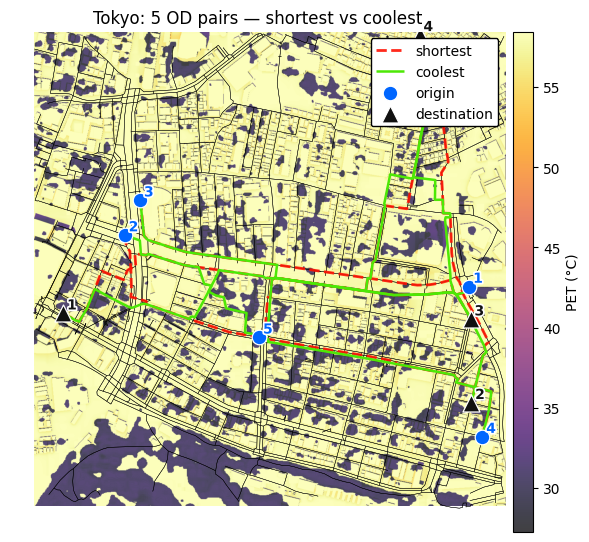

Saved combined map: outputs/Tokyo/routing/Tokyo_routes_20240621T0300_combined_n5.png
Saved summary: outputs/Tokyo/routing/Tokyo_routing_summary_20240621T0300_walk.csv


In [131]:
# Use the most recent PET raster and let it pick the best network (walk→fallback to drive)
_ = run_coolest_routing(latest_ts, n_pairs=5, plot_mode= "combined", make_plots=True, show_route_legend=True )

# _ = run_coolest_routing(latest_ts, n_pairs=100, plot_mode= "combined", make_plots=False)


In [ ]:
#@title Download generated image tiles
import zipfile
from pathlib import Path

# assumes you already have `prefix` defined elsewhere in your notebook
# e.g., prefix = "berlin_21jun"
root = Path("/content")
zip_path = root / f"{prefix}_jpgs.zip"   # <-- prefix added to ZIP filename

# --- settings ---
recursive = False    # set True to include subfolders
include_jpeg = False # set True to also include .jpeg

# collect files
files = []
if recursive:
    files.extend(root.rglob("*.jpg"))
    if include_jpeg:
        files.extend(root.rglob("*.jpeg"))
else:
    files.extend([p for p in root.iterdir() if p.is_file() and p.suffix.lower()==".jpg"])
    if include_jpeg:
        files.extend([p for p in root.iterdir() if p.is_file() and p.suffix.lower()==".jpeg"])

files = sorted(set(files))  # de-dup + stable order

if not files:
    print("No matching images found.")
else:
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for p in files:
            # keep original filenames inside the zip; change arcname if you want to rename inside the ZIP
            arcname = p.relative_to(root) if recursive else p.name
            zf.write(p, arcname=arcname)
    print(f"Created: {zip_path}")

    # auto-download in Colab (safe no-op elsewhere)
    try:
        from google.colab import files
        files.download(str(zip_path))
    except Exception:
        pass


Created: /content/Madrid_jpgs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Saved combined map: outputs/Los Angeles/routing/Los Angeles_routes_20240621T1900_combined_n10.png
# Saved summary: outputs/Los Angeles/routing/Los Angeles_routing_summary_20240621T1900_walk.csv
# [walk] Picked 100 OD pairs on graph with 646 nodes / 1824 edges
# Aggregated over all ODs → ΔLength: +1.8%   Heat↓: 3.2%   (n=100)

# Saved combined map: outputs/Toronto/routing/Toronto_routes_20240621T1600_combined_n10.png
# Saved summary: outputs/Toronto/routing/Toronto_routing_summary_20240621T1600_walk.csv
# [walk] Picked 100 OD pairs on graph with 876 nodes / 2222 edges
# Aggregated over all ODs → ΔLength: +1.1%   Heat↓: 3.3%   (n=100)
# Saved summary: outputs/Toronto/routing/Toronto_routing_summary_20240621T1600_walk.csv

# Saved combined map: outputs/Buenos Aires/routing/Buenos Aires_routes_20240621T1500_combined_n10.png
# Saved summary: outputs/Buenos Aires/routing/Buenos Aires_routing_summary_20240621T1500_walk.csv
# [walk] Picked 100 OD pairs on graph with 218 nodes / 652 edges
# Aggregated over all ODs → ΔLength: +0.9%   Heat↓: 3.1%   (n=100)
# Saved summary: outputs/Buenos Aires/routing/Buenos Aires_routing_summary_20240621T1500_walk.csv

# Saved combined map: outputs/Cairo/routing/Cairo_routes_20240621T0900_combined_n10.png
# Saved summary: outputs/Cairo/routing/Cairo_routing_summary_20240621T0900_walk.csv
# [walk] Picked 100 OD pairs on graph with 219 nodes / 614 edges
# Aggregated over all ODs → ΔLength: +0.4%   Heat↓: 0.6%   (n=100)
# Saved summary: outputs/Cairo/routing/Cairo_routing_summary_20240621T0900_walk.csv

# Saved combined map: outputs/Lagos/routing/Lagos_routes_20240621T1100_combined_n10.png
# Saved summary: outputs/Lagos/routing/Lagos_routing_summary_20240621T1100_walk.csv
# [walk] Picked 100 OD pairs on graph with 175 nodes / 440 edges
# Aggregated over all ODs → ΔLength: +0.0%   Heat↓: 0.1%   (n=100)
# Saved summary: outputs/Lagos/routing/Lagos_routing_summary_20240621T1100_walk.csv

# Saved combined map: outputs/Johannesburg/routing/Johannesburg_routes_20240621T1000_combined_n10.png
# Saved summary: outputs/Johannesburg/routing/Johannesburg_routing_summary_20240621T1000_walk.csv
# [walk] Picked 100 OD pairs on graph with 225 nodes / 688 edges
# Aggregated over all ODs → ΔLength: +0.7%   Heat↓: 2.7%   (n=100)
# Saved summary: outputs/Johannesburg/routing/Johannesburg_routing_summary_20240621T1000_walk.csv

# Saved combined map: outputs/Jakarta/routing/Jakarta_routes_20240621T0500_combined_n10.png
# Saved summary: outputs/Jakarta/routing/Jakarta_routing_summary_20240621T0500_walk.csv
# [walk] Picked 100 OD pairs on graph with 130 nodes / 352 edges
# Aggregated over all ODs → ΔLength: +0.2%   Heat↓: 0.2%   (n=100)
# Saved summary: outputs/Jakarta/routing/Jakarta_routing_summary_20240621T0500_walk.csv

# Saved combined map: outputs/Bangkok/routing/Bangkok_routes_20240621T0500_combined_n10.png
# Saved summary: outputs/Bangkok/routing/Bangkok_routing_summary_20240621T0500_walk.csv
# [walk] Picked 100 OD pairs on graph with 551 nodes / 1466 edges
# Aggregated over all ODs → ΔLength: +1.3%   Heat↓: 2.0%   (n=100)
# Saved summary: outputs/Bangkok/routing/Bangkok_routing_summary_20240621T0500_walk.csv

# Saved combined map: outputs/Seoul/routing/Seoul_routes_20240621T0300_combined_n10.png
# Saved summary: outputs/Seoul/routing/Seoul_routing_summary_20240621T0300_walk.csv
# [walk] Picked 100 OD pairs on graph with 517 nodes / 1368 edges
# Aggregated over all ODs → ΔLength: +0.9%   Heat↓: 0.9%   (n=100)
# Saved summary: outputs/Seoul/routing/Seoul_routing_summary_20240621T0300_walk.csv

# Saved combined map: outputs/Istanbul/routing/Istanbul_routes_20240621T0900_combined_n10.png
# Saved summary: outputs/Istanbul/routing/Istanbul_routing_summary_20240621T0900_walk.csv
# [walk] Picked 100 OD pairs on graph with 682 nodes / 2012 edges
# Aggregated over all ODs → ΔLength: +1.5%   Heat↓: 1.8%   (n=100)
# Saved summary: outputs/Istanbul/routing/Istanbul_routing_summary_20240621T0900_walk.csv

# Saved combined map: outputs/Santiago/routing/Santiago_routes_20240621T1600_combined_n10.png
# Saved summary: outputs/Santiago/routing/Santiago_routing_summary_20240621T1600_walk.csv
# [walk] Picked 100 OD pairs on graph with 403 nodes / 1138 edges
# Aggregated over all ODs → ΔLength: +6.3%   Heat↓: 23.8%   (n=100)
# Saved summary: outputs/Santiago/routing/Santiago_routing_summary_20240621T1600_walk.csv

# Saved combined map: outputs/Auckland/routing/Auckland_routes_20240621T0000_combined_n10.png
# Saved summary: outputs/Auckland/routing/Auckland_routing_summary_20240621T0000_walk.csv
# [walk] Picked 100 OD pairs on graph with 543 nodes / 1472 edges
# Aggregated over all ODs → ΔLength: +2.2%   Heat↓: 9.4%   (n=100)
# Saved summary: outputs/Auckland/routing/Auckland_routing_summary_20240621T0000_walk.csv

# Saved combined map: outputs/Perth/routing/Perth_routes_20240621T0400_combined_n10.png
# Saved summary: outputs/Perth/routing/Perth_routing_summary_20240621T0400_walk.csv
# [walk] Picked 100 OD pairs on graph with 913 nodes / 2606 edges
# Aggregated over all ODs → ΔLength: +2.8%   Heat↓: 6.7%   (n=100)
# Saved summary: outputs/Perth/routing/Perth_routing_summary_20240621T0400_walk.csv

# Saved combined map: outputs/Montevideo/routing/Montevideo_routes_20240621T1500_combined_n10.png
# Saved summary: outputs/Montevideo/routing/Montevideo_routing_summary_20240621T1500_walk.csv
# [walk] Picked 100 OD pairs on graph with 144 nodes / 416 edges
# Aggregated over all ODs → ΔLength: +0.5%   Heat↓: 0.6%   (n=100)
# Saved summary: outputs/Montevideo/routing/Montevideo_routing_summary_20240621T1500_walk.csv

# Saved combined map: outputs/Madrid/routing/Madrid_routes_20240621T1000_combined_n10.png
# Saved summary: outputs/Madrid/routing/Madrid_routing_summary_20240621T1000_walk.csv
# [walk] Picked 100 OD pairs on graph with 648 nodes / 1910 edges
# Aggregated over all ODs → ΔLength: +3.4%   Heat↓: 2.9%   (n=100)
# Saved summary: outputs/Madrid/routing/Madrid_routing_summary_20240621T1000_walk.csv